# Neural Image Caption Generation
## Sinh Mô Tả Ảnh Tự Động với Deep Learning (PyTorch + CLIP ViT-B/32 + Bahdanau Attention)

---

### Tóm Tắt

Dự án cài đặt hệ thống **Image Captioning** sử dụng **CLIP ViT-B/32** làm encoder trích xuất đặc trưng ảnh, kết hợp với **LSTM Decoder + Bahdanau Attention** để sinh caption tiếng Anh.

| Thành phần | Chi tiết |
|---|---|
| **Dataset** | Flickr30k (~31,783 ảnh × 5 captions) |
| **Image Encoder** | CLIP ViT-B/32 — 49 patch tokens × 512d (không fine-tune) |
| **Text Decoder** | LSTM-512 + Bahdanau Attention |
| **Embeddings** | GloVe 300d (fine-tunable) |
| **Framework** | PyTorch + MPS (Apple Silicon) |

### Tại sao CLIP tốt hơn CNN truyền thống?

| Encoder | Feature shape | Đặc điểm |
|---|---|---|
| VGG16 | (49, 512) | Low-level visual features |
| ResNet-101 | (49, 2048) | Deeper visual features |
| **CLIP ViT-B/32** | **(49, 512)** | **Vision-language aligned features — hiểu ngữ nghĩa tốt hơn** |

CLIP được pre-train trên 400 triệu cặp (ảnh, text) → feature đã học được mối quan hệ ngôn ngữ-thị giác, kỳ vọng cải thiện caption quality.

---


## Cell 2: Thiết lập Thư mục và Chẩn đoán Môi trường

**Mục đích:**
- Tự động tìm thư mục gốc của project
- Thiết lập `WORK_DIR` để lưu dataset, features, model
- In thông tin môi trường (OS, Python, Conda env)


In [1]:
# ─── BƯỚC 1: THIẾT LẬP THƯ MỤC ───────────────────────────────────────────────
from pathlib import Path
import os, platform, sys, subprocess

NOTEBOOK_FILENAME = 'ImageCaptioning_Flickr30k_CLIP.ipynb'

def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / NOTEBOOK_FILENAME).exists():
            return candidate
    return start.resolve()

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
WORK_DIR = PROJECT_ROOT / 'workspace'
WORK_DIR.mkdir(parents=True, exist_ok=True)

IS_MACOS         = platform.system() == 'Darwin'
IS_APPLE_SILICON = IS_MACOS and platform.machine() == 'arm64'

# ─── BƯỚC 2: IN THÔNG TIN MÔI TRƯỜNG ─────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  THIẾT LẬP MÔI TRƯỜNG – CLIP ViT-B/32")
print(SEP)
print(f"  Project root   : {PROJECT_ROOT}")
print(f"  Work dir       : {WORK_DIR}")
print(f"  Python         : {sys.version.split()[0]}")
print(f"  Executable     : {sys.executable}")
print(f"  OS             : {platform.system()} {platform.release()}")
print(f"  Architecture   : {platform.machine()}")
print(f"  Apple Silicon  : {IS_APPLE_SILICON}")

conda_env = os.environ.get('CONDA_DEFAULT_ENV', 'N/A')
venv      = os.environ.get('VIRTUAL_ENV', 'N/A')
print(f"  Conda env      : {conda_env}")
print(f"  Virtual env    : {venv}")

# ─── BƯỚC 3: KIỂM TRA CÁC THƯ MỤC ───────────────────────────────────────────
subdirs = ['Flicker30k_Dataset', 'models']
print(f"\n  Trạng thái thư mục con trong workspace/:")
for sub in subdirs:
    path = WORK_DIR / sub
    exists = path.exists()
    n_files = len(list(path.iterdir())) if exists else 0
    status  = f"✅  {n_files} files" if exists else "❌  Chưa có"
    print(f"    {sub:<25} {status}")

glove_files = ['glove.6B.300d.txt', 'glove.6B.100d.txt']
print(f"\n  GloVe files:")
for gf in glove_files:
    gp = PROJECT_ROOT / gf
    print(f"    {gf:<25} {'✅ Found' if gp.exists() else '❌ Not found'}")
print(SEP)


  THIẾT LẬP MÔI TRƯỜNG – CLIP ViT-B/32
  Project root   : /Applications/Python_AI/Neural_Image_Caption_Generation
  Work dir       : /Applications/Python_AI/Neural_Image_Caption_Generation/workspace
  Python         : 3.10.20
  Executable     : /opt/anaconda3/envs/tf-metal/bin/python
  OS             : Darwin 25.3.0
  Architecture   : arm64
  Apple Silicon  : True
  Conda env      : tf-metal
  Virtual env    : N/A

  Trạng thái thư mục con trong workspace/:
    Flicker30k_Dataset        ✅  31784 files
    models                    ✅  14 files

  GloVe files:
    glove.6B.300d.txt         ✅ Found
    glove.6B.100d.txt         ✅ Found


## Cell 3: Kiểm tra Package và Phát hiện Thiết bị (GPU/MPS/CPU)

**Mục đích:**
- Cài tự động các package còn thiếu (bao gồm **openai-clip**)
- Phát hiện thiết bị tính toán: NVIDIA CUDA / Apple MPS / CPU
- In thông tin chi tiết về RAM và thiết bị

**Lưu ý về CLIP:**
- Package: `pip install openai-clip` (hoặc `pip install git+https://github.com/openai/CLIP.git`)
- Model `ViT-B/32` sẽ được tải tự động (~350MB) lần đầu tiên chạy


In [2]:
# ─── BƯỚC 1: KIỂM TRA VÀ CÀI PACKAGE ────────────────────────────────────────
import importlib, importlib.util

REQUIRED_PACKAGES = {
    'torch'       : 'torch',
    'torchvision' : 'torchvision',
    'PIL'         : 'pillow',
    'nltk'        : 'nltk',
    'matplotlib'  : 'matplotlib',
    'tqdm'        : 'tqdm',
    'numpy'       : 'numpy',
    'clip'        : 'openai-clip',
    'psutil'      : 'psutil',
}

missing = []
for module, pkg in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module) is None:
        missing.append(pkg)

if missing:
    print(f"Đang cài các package còn thiếu: {missing}")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
    print("✅  Cài đặt xong.")
else:
    print("✅  Tất cả package đã sẵn sàng (bao gồm openai-clip).")

# ─── BƯỚC 2: DOWNLOAD NLTK DATA ──────────────────────────────────────────────
import nltk
for resource in ['punkt', 'punkt_tab']:
    try:
        nltk.data.find(f'tokenizers/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

# ─── BƯỚC 3: PHÁT HIỆN THIẾT BỊ ─────────────────────────────────────────────
import torch

SEP = "=" * 65
print(f"\n{SEP}")
print("  THÔNG TIN THIẾT BỊ TÍNH TOÁN")
print(SEP)
print(f"  PyTorch version  : {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device('cuda')
    gpu_name   = torch.cuda.get_device_name(0)
    gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"  Device           : NVIDIA CUDA GPU")
    print(f"  GPU Name         : {gpu_name}")
    print(f"  GPU Memory       : {gpu_mem_gb:.1f} GB")
    print(f"  CUDA Version     : {torch.version.cuda}")
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    import psutil
    ram_gb = psutil.virtual_memory().total / (1024**3)
    print(f"  Device           : Apple MPS (Metal Performance Shaders)")
    print(f"  System RAM       : {ram_gb:.1f} GB  (shared GPU/CPU memory)")
    print(f"  MPS available    : {torch.backends.mps.is_available()}")
    print(f"  MPS built        : {torch.backends.mps.is_built()}")
else:
    device = torch.device('cpu')
    print(f"  Device           : CPU (no GPU detected)")

print(f"\n  ➜  Using device  : {device}")
print(SEP)


✅  Tất cả package đã sẵn sàng (bao gồm openai-clip).

  THÔNG TIN THIẾT BỊ TÍNH TOÁN
  PyTorch version  : 2.11.0
  Device           : Apple MPS (Metal Performance Shaders)
  System RAM       : 16.0 GB  (shared GPU/CPU memory)
  MPS available    : True
  MPS built        : True

  ➜  Using device  : mps


## Cell 4: Import Tất cả Thư viện

**Mục đích:** Tập trung toàn bộ import vào một cell duy nhất.

| Nhóm | Thư viện |
|------|----------|
| 1 – Tính toán cơ bản | `os`, `sys`, `re`, `json`, `pickle`, `math`, `random` |
| 2 – NLP | `nltk` (BLEU), `re` |
| 3 – Ảnh | `PIL` |
| 4 – Deep Learning | `torch`, `torchvision`, **`clip`** |
| 5 – Đánh giá & Visualize | `matplotlib`, `numpy` |


In [3]:
# ─── NHÓM 1: THƯ VIỆN TÍNH TOÁN CƠ BẢN ─────────────────────────────────────
import os, sys, re, json, math, random, gc, time
import pickle
import string
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional

# ─── NHÓM 2: XỬ LÝ VĂN BẢN ──────────────────────────────────────────────────
import nltk
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# ─── NHÓM 3: XỬ LÝ FILE VÀ ẢNH ──────────────────────────────────────────────
from PIL import Image

# ─── NHÓM 4: PYTORCH + CLIP ──────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as transforms
import clip
from tqdm import tqdm

# ─── NHÓM 5: ĐÁNH GIÁ VÀ TRỰC QUAN ──────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'figure.dpi'       : 110,
    'axes.titlesize'   : 11,
    'axes.labelsize'   : 10,
    'font.family'      : 'DejaVu Sans',
})

# ─── TỔNG KẾT ─────────────────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  TỔNG KẾT IMPORT")
print(SEP)
libs = {
    'numpy'      : np.__version__,
    'torch'      : torch.__version__,
    'PIL'        : Image.__version__,
    'matplotlib' : matplotlib.__version__,
    'nltk'       : nltk.__version__,
    'clip'       : clip.__version__ if hasattr(clip, '__version__') else 'openai-clip',
}
for lib, ver in libs.items():
    print(f"  {lib:<15} v{ver}")
print(f"  Device: {device}")
print(SEP)


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


  TỔNG KẾT IMPORT
  numpy           v1.26.4
  torch           v2.11.0
  PIL             v12.1.1
  matplotlib      v3.10.8
  nltk            v3.9.3
  clip            vopenai-clip
  Device: mps


## Cell 5: Cấu hình và Hằng số

**Mục đích:** Tập trung **tất cả tham số** vào một nơi — tránh "magic numbers".

| Phần | Nội dung |
|------|----------|
| 1 – Đường dẫn | Vị trí file dataset, features, model (prefix `clip_`) |
| 2 – CLIP params | Model name, feature dim, spatial grid |
| 3 – Model params | Vocab, embed dim, LSTM hidden |
| 4 – Training | Batch size, **epochs=10**, learning rate |

**CLIP ViT-B/32 feature shape:**
```
Input image: 224×224
→ Patch size: 32×32
→ Spatial grid: 7×7 = 49 patches
→ Feature shape: (49, 512)  ← tương đương VGG16 (49, 512)
```


In [4]:
# ─── PHẦN 1: ĐƯỜNG DẪN FILE VÀ FOLDER ───────────────────────────────────────
IMAGE_DIR       = WORK_DIR / 'Flicker30k_Dataset'
CAPTIONS_CSV    = WORK_DIR / 'results.csv'

# ⚠️ Dùng prefix clip_ — không bị ghi đè lên artifact của VGG16/ResNet
FEATURES_PATH   = WORK_DIR / 'features_clip_flickr30k.pkl'
DESC_PATH       = WORK_DIR / 'descriptions_flickr30k.txt'      # shared với VGG16
TOKENIZER_PATH  = WORK_DIR / 'tokenizer_clip_flickr30k.pkl'
SPLITS_PATH     = WORK_DIR / 'flickr30k_splits.json'           # shared splits
MODEL_DIR       = WORK_DIR / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH      = MODEL_DIR / 'caption_clip_flickr30k_best.pt'
HISTORY_PATH    = MODEL_DIR / 'training_history_clip_flickr30k.json'

GLOVE_SEARCH_PATHS = [
    PROJECT_ROOT / 'glove.6B.300d.txt',
    PROJECT_ROOT / 'glove.6B' / 'glove.6B.300d.txt',
    WORK_DIR / 'glove' / 'glove.6B.300d.txt',
    PROJECT_ROOT / 'glove.6B.100d.txt',
    WORK_DIR / 'glove.6B.100d.txt',
]

# ─── PHẦN 2: THAM SỐ CLIP ViT-B/32 ──────────────────────────────────────────
CLIP_MODEL_NAME = "ViT-B/32"   # hoặc "ViT-B/16" nếu muốn tốt hơn
IMG_SIZE        = 224          # CLIP input size
FEATURE_SIZE    = 512          # CLIP projection dim (ViT-B/32 output)
NUM_REGIONS     = 49           # 7×7 patch grid → 49 spatial tokens

# ─── PHẦN 3: THAM SỐ MODEL ───────────────────────────────────────────────────
VOCAB_SIZE     = 10_000
MAX_LENGTH     = 35
EMBED_DIM      = 300           # GloVe 300d
HIDDEN_SIZE    = 512
DROPOUT        = 0.5
EMBED_TRAINABLE = True

# ─── PHẦN 4: THAM SỐ TRAINING ────────────────────────────────────────────────
BATCH_SIZE            = 64
EPOCHS                = 10     # quick experiment: 10 epochs
LEARNING_RATE         = 1e-4
WEIGHT_DECAY          = 1e-4
GRAD_CLIP             = 5.0
LABEL_SMOOTHING       = 0.1
LR_PATIENCE           = 2
LR_FACTOR             = 0.5
EARLY_STOP_PATIENCE   = 5
BEAM_WIDTH            = 5
FORCE_RETRAIN         = False

# ─── PHẦN 5: SPLIT RATIOS ─────────────────────────────────────────────────────
SPLIT_SEED = 42
N_VAL      = 1_014
N_TEST     = 1_000

# ─── TỔNG KẾT CẤU HÌNH ────────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  TỔNG KẾT CẤU HÌNH – CLIP ViT-B/32 + Flickr30k")
print(SEP)
sections = {
    "CLIP ENCODER": {
        "Model"          : CLIP_MODEL_NAME,
        "Image size"     : f"{IMG_SIZE}×{IMG_SIZE}",
        "Feature size"   : f"{FEATURE_SIZE}d",
        "Spatial regions": f"{NUM_REGIONS} patches (7×7)",
        "Feature file"   : FEATURES_PATH.name,
    },
    "DATASET": {
        "Dataset"        : "Flickr30k (31,783 ảnh × 5 captions)",
        "Image dir"      : IMAGE_DIR,
        "Model path"     : MODEL_PATH.name,
    },
    "SPLITS": {
        "Train"          : f"~{31783 - N_VAL - N_TEST:,} ảnh",
        "Val"            : f"{N_VAL:,} ảnh",
        "Test"           : f"{N_TEST:,} ảnh",
    },
    "THAM SỐ MODEL": {
        "Vocab size"     : f"{VOCAB_SIZE:,}",
        "Max length"     : MAX_LENGTH,
        "Embed dim"      : EMBED_DIM,
        "LSTM hidden"    : HIDDEN_SIZE,
        "Dropout"        : DROPOUT,
    },
    "THAM SỐ TRAINING": {
        "Batch size"     : BATCH_SIZE,
        "Epochs"         : EPOCHS,
        "Learning rate"  : LEARNING_RATE,
        "Weight decay"   : WEIGHT_DECAY,
        "Grad clip"      : GRAD_CLIP,
        "Early stop"     : EARLY_STOP_PATIENCE,
        "Beam width"     : BEAM_WIDTH,
    },
}
for section, params in sections.items():
    print(f"\n  [{section}]")
    for k, v in params.items():
        print(f"    {k:<20} : {v}")
print(f"\n{SEP}")


  TỔNG KẾT CẤU HÌNH – CLIP ViT-B/32 + Flickr30k

  [CLIP ENCODER]
    Model                : ViT-B/32
    Image size           : 224×224
    Feature size         : 512d
    Spatial regions      : 49 patches (7×7)
    Feature file         : features_clip_flickr30k.pkl

  [DATASET]
    Dataset              : Flickr30k (31,783 ảnh × 5 captions)
    Image dir            : /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/Flicker30k_Dataset
    Model path           : caption_clip_flickr30k_best.pt

  [SPLITS]
    Train                : ~29,769 ảnh
    Val                  : 1,014 ảnh
    Test                 : 1,000 ảnh

  [THAM SỐ MODEL]
    Vocab size           : 10,000
    Max length           : 35
    Embed dim            : 300
    LSTM hidden          : 512
    Dropout              : 0.5

  [THAM SỐ TRAINING]
    Batch size           : 64
    Epochs               : 10
    Learning rate        : 0.0001
    Weight decay         : 0.0001
    Grad clip            : 5.0
    

## Cell 6: Khám phá Dataset – Exploratory Data Analysis (EDA)

**Mục đích:** *"Hiểu dữ liệu trước khi code"*
- Kiểm tra số lượng file ảnh và captions
- Phân phối kích thước ảnh, độ dài caption
- Xem mẫu ảnh từ dataset

| Phần | Nội dung |
|------|----------|
| 1 | Kiểm tra file ảnh và CSV |
| 2 | Thống kê captions |
| 3 | Phân phối kích thước ảnh |
| 4 | Hiển thị ảnh mẫu |


  PART 1: IMAGE FILE CHECK – FLICKR30K
  Số ảnh tìm thấy : 31,783
  Thư mục ảnh     : /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/Flicker30k_Dataset
  File captions   : /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/results.csv
  File size CSV   : 13.3 MB

  Tổng captions   : 158,915
  Ảnh unique      : 31,783
  Avg caps/image  : 5.0
  Avg cap length  : 13.4 words
  Max cap length  : 82 words

  Kiểm tra 5 ảnh đầu tiên:
    OK: 100/100  |  Lỗi: 0/100


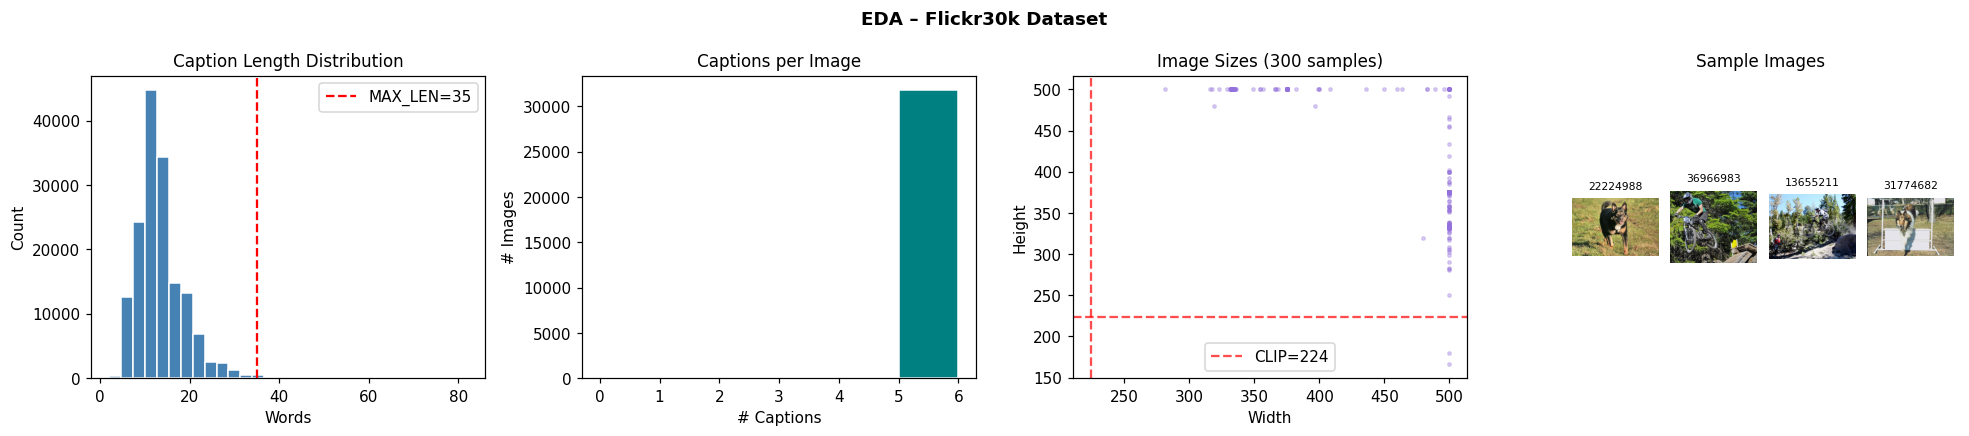

In [5]:
# ─── PHẦN 1: KIỂM TRA FILE ẢNH ───────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  PART 1: IMAGE FILE CHECK – FLICKR30K")
print(SEP)

assert IMAGE_DIR.exists(),    f"❌ Không tìm thấy ảnh: {IMAGE_DIR}"
assert CAPTIONS_CSV.exists(), f"❌ Không tìm thấy captions: {CAPTIONS_CSV}"

image_list = sorted([f for f in IMAGE_DIR.iterdir()
                     if f.suffix.lower() in ('.jpg','.jpeg','.png')])
print(f"  Số ảnh tìm thấy : {len(image_list):,}")
print(f"  Thư mục ảnh     : {IMAGE_DIR}")
print(f"  File captions   : {CAPTIONS_CSV}")
print(f"  File size CSV   : {CAPTIONS_CSV.stat().st_size / 1e6:.1f} MB")

# ─── PHẦN 2: ĐỌC CAPTIONS NHANH ─────────────────────────────────────────────
with open(CAPTIONS_CSV, encoding='utf-8') as f:
    lines = f.readlines()[1:]  # skip header

cap_counts  = Counter()
cap_lengths = []
for line in lines:
    parts = line.strip().split('|')
    if len(parts) >= 3:
        img_id = parts[0].strip().split('.')[0]
        cap_counts[img_id] += 1
        cap_lengths.append(len(parts[2].strip().split()))

print(f"\n  Tổng captions   : {len(lines):,}")
print(f"  Ảnh unique      : {len(cap_counts):,}")
print(f"  Avg caps/image  : {sum(cap_counts.values())/len(cap_counts):.1f}")
print(f"  Avg cap length  : {sum(cap_lengths)/len(cap_lengths):.1f} words")
print(f"  Max cap length  : {max(cap_lengths)} words")

# ─── PHẦN 3: KIỂM TRA ẢNH MẪU ────────────────────────────────────────────────
print(f"\n  Kiểm tra 5 ảnh đầu tiên:")
ok, fail = 0, 0
for fpath in image_list[:100]:
    try:
        img = Image.open(fpath)
        ok += 1
    except Exception:
        fail += 1
print(f"    OK: {ok}/100  |  Lỗi: {fail}/100")

# ─── PHẦN 4: TRỰC QUAN (4 BIỂU ĐỒ) ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('EDA – Flickr30k Dataset', fontweight='bold')

axes[0].hist(cap_lengths, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(MAX_LENGTH, color='red', linestyle='--', label=f'MAX_LEN={MAX_LENGTH}')
axes[0].set_title('Caption Length Distribution')
axes[0].set_xlabel('Words'); axes[0].set_ylabel('Count'); axes[0].legend()

cap_per_img = list(cap_counts.values())
axes[1].hist(cap_per_img, bins=range(0, max(cap_per_img)+2), color='teal', edgecolor='white')
axes[1].set_title('Captions per Image')
axes[1].set_xlabel('# Captions'); axes[1].set_ylabel('# Images')

sample_sizes = []
for fpath in random.sample(image_list, min(300, len(image_list))):
    try:
        img = Image.open(fpath)
        sample_sizes.append(img.size)
    except Exception:
        pass
widths  = [s[0] for s in sample_sizes]
heights = [s[1] for s in sample_sizes]
axes[2].scatter(widths, heights, alpha=0.3, s=5, color='mediumpurple')
axes[2].axvline(224, color='red', linestyle='--', alpha=0.7, label='CLIP=224')
axes[2].axhline(224, color='red', linestyle='--', alpha=0.7)
axes[2].set_title('Image Sizes (300 samples)')
axes[2].set_xlabel('Width'); axes[2].set_ylabel('Height'); axes[2].legend()

sample_imgs = random.sample(image_list, 4)
for i, fpath in enumerate(sample_imgs):
    inset = axes[3].inset_axes([0.02 + i*0.25, 0.1, 0.22, 0.8])
    inset.imshow(Image.open(fpath).convert('RGB'))
    inset.axis('off')
    inset.set_title(fpath.stem[:8], fontsize=7)
axes[3].axis('off')
axes[3].set_title('Sample Images')

plt.tight_layout(); plt.show()
print(SEP)


## Cell 7: Trích xuất Features bằng CLIP ViT-B/32 (PyTorch)

**Mục đích:** Chuyển mỗi ảnh từ pixel `(224×224×3)` → vector đặc trưng lưới `(49×512)`.

```
CLIP ViT-B/32 Architecture:
  Input    : (B, 3, 224, 224)
  Patch    : 32×32 → chia thành 7×7 = 49 patches
  conv1    : (B, 768, 7, 7)     ← patch embedding
  Flatten  : (B, 49, 768)
  + CLS    : (B, 50, 768)       ← thêm class token
  + PosEmb : (B, 50, 768)       ← positional embedding
  Transformer (12 layers)
  → patch tokens: (B, 49, 768)  ← bỏ CLS token
  → ln_post + proj: (B, 49, 512) ← projection 768→512
  Output   : (49, 512) per image
```

**Ưu điểm so với VGG16/ResNet:**
- CLIP được pre-train trên 400M cặp (ảnh, text) từ internet → features "hiểu" ngôn ngữ
- Cùng shape `(49, 512)` với VGG16 → reuse decoder không đổi gì
- Features đã normalize trong không gian embedding chung với text

**Lưu ý:**
- CLIP model (~350MB) sẽ tự tải về lần đầu tiên
- `clip_model` bị freeze hoàn toàn — không fine-tune
- Sau khi extract xong, features được cache vào `features_clip_flickr30k.pkl`


  CLIP ViT-B/32 FEATURE EXTRACTION
  Loading CLIP ViT-B/32 (downloading ~350MB if first run)...
  CLIP model loaded:
    Total params      : 151.3M
    ViT internal dim  : 768
    Patch size        : 32×32
    Spatial grid      : 7×7 = 49 patches  ✅
    Projection dim    : 512d  ✅
    Output per image  : (49, 512)

  Extracting features for 31,783 images...


CLIP extract: 100%|██████████| 994/994 [04:21<00:00,  3.81it/s]


  Done: 31,783 images in 261.1s  (122 img/s)
  ✅ Saved features → /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/features_clip_flickr30k.pkl

  FEATURE VERIFICATION


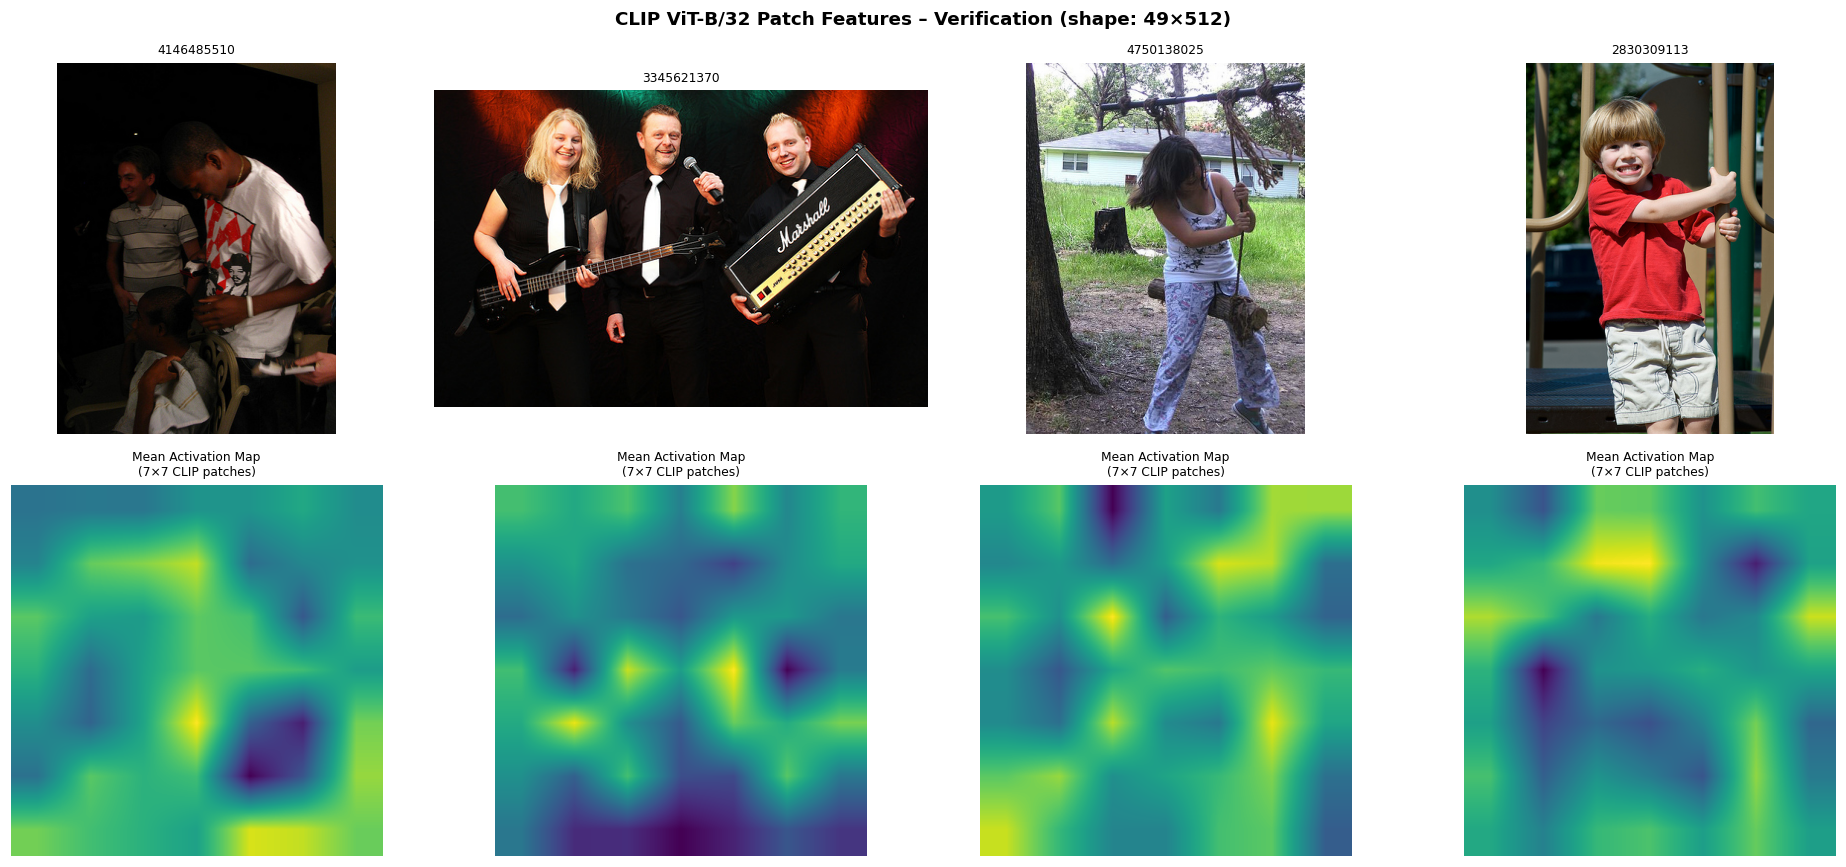

  Sample shape    : (49, 512)
  Total images    : 31,783
  Global mean     : -0.0072
  Global std      : 0.3124
  Min / Max       : -6.5433 / 2.9634


In [7]:
# ─── BƯỚC 1: TẢI CLIP MODEL ──────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  CLIP ViT-B/32 FEATURE EXTRACTION")
print(SEP)

if FEATURES_PATH.exists() and not FORCE_RETRAIN:
    print(f"  ✅ Features found: {FEATURES_PATH}")
    print("  Loading cached features...")
    with open(FEATURES_PATH, 'rb') as f:
        features_conv = pickle.load(f)
    sample_shape = list(features_conv.values())[0].shape
    print(f"  Loaded {len(features_conv):,} images. Shape: {sample_shape}")
    assert sample_shape == (NUM_REGIONS, FEATURE_SIZE), \
        f"❌ Feature shape mismatch: expected ({NUM_REGIONS},{FEATURE_SIZE}), got {sample_shape}"
else:
    print(f"  Loading CLIP {CLIP_MODEL_NAME} (downloading ~350MB if first run)...")
    clip_model, _ = clip.load(CLIP_MODEL_NAME, device=device)
    clip_model = clip_model.float()   # cast to float32 — MPS requires input/weight same dtype
    clip_model.eval()
    for param in clip_model.parameters():
        param.requires_grad = False

    # Thống kê model
    vit = clip_model.visual
    total_params = sum(p.numel() for p in clip_model.parameters())
    # Validate patch count matches NUM_REGIONS config
    img_size_patches = (IMG_SIZE // vit.conv1.kernel_size[0]) ** 2
    assert img_size_patches == NUM_REGIONS, (
        f"❌ Config mismatch: CLIP '{CLIP_MODEL_NAME}' produces {img_size_patches} patches "
        f"but NUM_REGIONS={NUM_REGIONS}. "
        f"Fix: set NUM_REGIONS={img_size_patches} in Cell 5."
    )
    proj_dim = vit.proj.shape[-1] if vit.proj is not None else vit.conv1.out_channels
    assert proj_dim == FEATURE_SIZE, (
        f"❌ Config mismatch: CLIP projection dim={proj_dim} but FEATURE_SIZE={FEATURE_SIZE}."
    )

    print(f"  CLIP model loaded:")
    print(f"    Total params      : {total_params/1e6:.1f}M")
    print(f"    ViT internal dim  : {vit.conv1.out_channels}")
    print(f"    Patch size        : {vit.conv1.kernel_size[0]}×{vit.conv1.kernel_size[0]}")
    print(f"    Spatial grid      : {int(img_size_patches**0.5)}×{int(img_size_patches**0.5)} = {img_size_patches} patches  ✅")
    print(f"    Projection dim    : {proj_dim}d  ✅")
    print(f"    Output per image  : ({NUM_REGIONS}, {FEATURE_SIZE})")

    # ─── HÀM TRÍCH XUẤT PATCH TOKENS ─────────────────────────────────────────
    def extract_patch_features(pixel_values: torch.Tensor) -> torch.Tensor:
        """
        Trích xuất 49 patch tokens từ CLIP ViT-B/32.
        Bỏ CLS token (index 0), lấy 49 patch tokens → project → (B, 49, 512).

        Pipeline:
          conv1 → flatten → prepend CLS → +posemb → transformer
          → lấy patch[:,1:,:] → ln_post → @ proj
        """
        vit = clip_model.visual
        with torch.no_grad():
            x = vit.conv1(pixel_values)              # (B, 768, 7, 7)
            B, D, H, W = x.shape
            x = x.reshape(B, D, H * W).permute(0, 2, 1)    # (B, 49, 768)

            cls = vit.class_embedding.unsqueeze(0).unsqueeze(0).expand(B, -1, -1)
            x   = torch.cat([cls, x], dim=1)                # (B, 50, 768)
            x   = x + vit.positional_embedding.unsqueeze(0) # (B, 50, 768)
            x   = vit.ln_pre(x)

            x   = x.permute(1, 0, 2)    # (50, B, 768) — transformer expects seq-first
            x   = vit.transformer(x)
            x   = x.permute(1, 0, 2)    # (B, 50, 768)

            # Bỏ CLS (index 0), giữ 49 patch tokens
            patches = x[:, 1:, :]       # (B, 49, 768)
            patches = vit.ln_post(patches)
            if vit.proj is not None:
                patches = patches @ vit.proj   # (B, 49, 512)
        return patches.float()

    # Transform theo chuẩn CLIP (khác ImageNet)
    clip_transform = transforms.Compose([
        transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.48145466, 0.4578275,  0.40821073],
            std =[0.26862954, 0.26130258, 0.27577711],
        ),
    ])

    # ─── TRÍCH XUẤT TẤT CẢ ẢNH ──────────────────────────────────────────────
    image_list = sorted([f for f in IMAGE_DIR.iterdir()
                         if f.suffix.lower() in ('.jpg','.jpeg','.png')])
    print(f"\n  Extracting features for {len(image_list):,} images...")
    BATCH_SIZE_EXTRACT = 32
    start_time = time.time()

    features_conv = {}
    errors        = []

    for i in tqdm(range(0, len(image_list), BATCH_SIZE_EXTRACT), desc='CLIP extract'):
        batch_paths  = image_list[i : i + BATCH_SIZE_EXTRACT]
        batch_tensors = []
        batch_ids     = []

        for fpath in batch_paths:
            try:
                img = Image.open(fpath).convert('RGB')
                batch_tensors.append(clip_transform(img))
                batch_ids.append(fpath.stem)
            except Exception as e:
                errors.append((fpath.name, str(e)))

        if not batch_tensors:
            continue

        batch = torch.stack(batch_tensors).to(device)      # (B, 3, 224, 224)
        feats = extract_patch_features(batch)               # (B, 49, 512)
        feats = feats.cpu().numpy().astype('float32')

        for img_id, feat in zip(batch_ids, feats):
            features_conv[img_id] = feat                   # (49, 512)

    elapsed = time.time() - start_time
    print(f"  Done: {len(features_conv):,} images in {elapsed:.1f}s  "
          f"({len(features_conv)/elapsed:.0f} img/s)")
    if errors:
        print(f"  Errors: {len(errors)} images")

    with open(FEATURES_PATH, 'wb') as f:
        pickle.dump(features_conv, f)
    print(f"  ✅ Saved features → {FEATURES_PATH}")

    del clip_model
    gc.collect()

# ─── BƯỚC 2: VERIFICATION ────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  FEATURE VERIFICATION")
print(SEP)

sample_ids   = random.sample(list(features_conv.keys()), 4)
sample_feats = [features_conv[k] for k in sample_ids]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('CLIP ViT-B/32 Patch Features – Verification (shape: 49×512)',
             fontweight='bold')

for col, (img_id, feat) in enumerate(zip(sample_ids, sample_feats)):
    img_path = IMAGE_DIR / f"{img_id}.jpg"
    if img_path.exists():
        axes[0, col].imshow(Image.open(img_path).convert('RGB'))
        axes[0, col].set_title(img_id[:15], fontsize=8)
    axes[0, col].axis('off')

    feat_mean = feat.mean(axis=-1).reshape(7, 7)   # mean across 512 channels
    axes[1, col].imshow(feat_mean, cmap='viridis', interpolation='bilinear')
    axes[1, col].set_title('Mean Activation Map\n(7×7 CLIP patches)', fontsize=8)
    axes[1, col].axis('off')

plt.tight_layout(); plt.show()

all_sample = np.stack(random.sample(list(features_conv.values()), 200))
print(f"  Sample shape    : {list(features_conv.values())[0].shape}")
print(f"  Total images    : {len(features_conv):,}")
print(f"  Global mean     : {all_sample.mean():.4f}")
print(f"  Global std      : {all_sample.std():.4f}")
print(f"  Min / Max       : {all_sample.min():.4f} / {all_sample.max():.4f}")
print(SEP)


## Cell 8: Parse Captions (Flickr30k)

**Mục đích:** Chuyển file `results.csv` (Flickr30k) thành dict `{image_id: [cap1, cap2, cap3, cap4, cap5]}`

```
Format gốc (pipe-separated):
  1000092795.jpg| 0| Two young guys with shaggy hair look at their hands...
  1000092795.jpg| 1| Two young, White males are outside near many bushes.
  ...

Format sau parse:
  {"1000092795": ["Two young guys...", "Two young, White males...", ...]}
```

**Lưu ý:** Chia sẻ file `flickr30k_splits.json` với VGG16/ResNet101 (cùng seed=42) → splits đồng nhất, kết quả BLEU so sánh được.


In [8]:
# ─── BƯỚC 1: ĐỌC FILE results.csv ───────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  PARSE CAPTIONS – FLICKR30K (results.csv)")
print(SEP)

assert CAPTIONS_CSV.exists(), f"❌ Không tìm thấy: {CAPTIONS_CSV}"
assert IMAGE_DIR.exists(),    f"❌ Không tìm thấy: {IMAGE_DIR}"

with open(CAPTIONS_CSV, encoding='utf-8') as f:
    lines = f.readlines()

print(f"  File captions : {CAPTIONS_CSV}")
print(f"  Tổng dòng     : {len(lines):,}  (gồm 1 dòng header)")
print(f"  3 dòng mẫu:")
for line in lines[1:4]:
    print(f"    {line.strip()[:90]}")

# ─── BƯỚC 2: PARSE ────────────────────────────────────────────────────────────
all_descriptions = {}
parse_errors = 0
for line in lines[1:]:
    parts = line.strip().split('|')
    if len(parts) < 3:
        parse_errors += 1
        continue
    img_id  = parts[0].strip().split('.')[0]
    caption = parts[2].strip()
    if img_id not in all_descriptions:
        all_descriptions[img_id] = []
    all_descriptions[img_id].append(caption)

print(f"\n  Số ảnh (unique)   : {len(all_descriptions):,}")
print(f"  Tổng captions     : {sum(len(v) for v in all_descriptions.values()):,}")
print(f"  Captions/ảnh      : {sum(len(v) for v in all_descriptions.values())/len(all_descriptions):.1f}")
print(f"  Parse errors      : {parse_errors}")

# ─── BƯỚC 3: TRAIN/VAL/TEST SPLITS ───────────────────────────────────────────
print(f"\n{SEP}")
print("  TẠO / TẢI TRAIN / VAL / TEST SPLITS")
print(SEP)

if SPLITS_PATH.exists() and not FORCE_RETRAIN:
    with open(SPLITS_PATH) as f:
        splits = json.load(f)
    train_ids = set(splits['train'])
    dev_ids   = set(splits['val'])
    test_ids  = set(splits['test'])
    print(f"  ✅ Load splits từ file: {SPLITS_PATH}")
else:
    import random as _random
    _random.seed(SPLIT_SEED)
    all_ids = list(all_descriptions.keys())
    _random.shuffle(all_ids)
    test_ids  = set(all_ids[:N_TEST])
    dev_ids   = set(all_ids[N_TEST : N_TEST + N_VAL])
    train_ids = set(all_ids[N_TEST + N_VAL:])
    splits = {'train': list(train_ids), 'val': list(dev_ids),
              'test': list(test_ids), 'seed': SPLIT_SEED}
    with open(SPLITS_PATH, 'w') as f:
        json.dump(splits, f)
    print(f"  ✅ Đã tạo và lưu splits → {SPLITS_PATH}")

print(f"  Train : {len(train_ids):,} ảnh")
print(f"  Val   : {len(dev_ids):,} ảnh")
print(f"  Test  : {len(test_ids):,} ảnh")
assert len(train_ids & dev_ids) == 0 and len(train_ids & test_ids) == 0
print(f"  ✅ Splits không overlap – OK")
print(SEP)


  PARSE CAPTIONS – FLICKR30K (results.csv)
  File captions : /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/results.csv
  Tổng dòng     : 158,916  (gồm 1 dòng header)
  3 dòng mẫu:
    1000092795.jpg| 0| Two young guys with shaggy hair look at their hands while hanging out i
    1000092795.jpg| 1| Two young , White males are outside near many bushes .
    1000092795.jpg| 2| Two men in green shirts are standing in a yard .

  Số ảnh (unique)   : 31,783
  Tổng captions     : 158,914
  Captions/ảnh      : 5.0
  Parse errors      : 1

  TẠO / TẢI TRAIN / VAL / TEST SPLITS
  ✅ Load splits từ file: /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/flickr30k_splits.json
  Train : 29,769 ảnh
  Val   : 1,014 ảnh
  Test  : 1,000 ảnh
  ✅ Splits không overlap – OK


## Cell 9: Làm sạch Captions

**Mục đích:** Chuẩn hoá captions để giảm vocabulary size và cải thiện chất lượng training.

**Các bước làm sạch:**
1. Chuyển chữ thường (lowercase)
2. Xoá ký tự không phải chữ cái và apostrophe
3. Giữ lại từ có độ dài ≥ 1 (bao gồm "a", "i")
4. Thêm `startseq` và `endseq`

**Chia sẻ file:** `descriptions_flickr30k.txt` dùng chung với VGG16/ResNet101 nếu đã có.


  CAPTION CLEANING
  BEFORE CLEANING:
    Vocab size     : 23,457
    Total tokens   : 2,127,766
    Avg cap length : 13.39 words

  AFTER CLEANING:
    Vocab size     : 18,098
    Avg cap length : 14.30 words (incl. startseq/endseq)


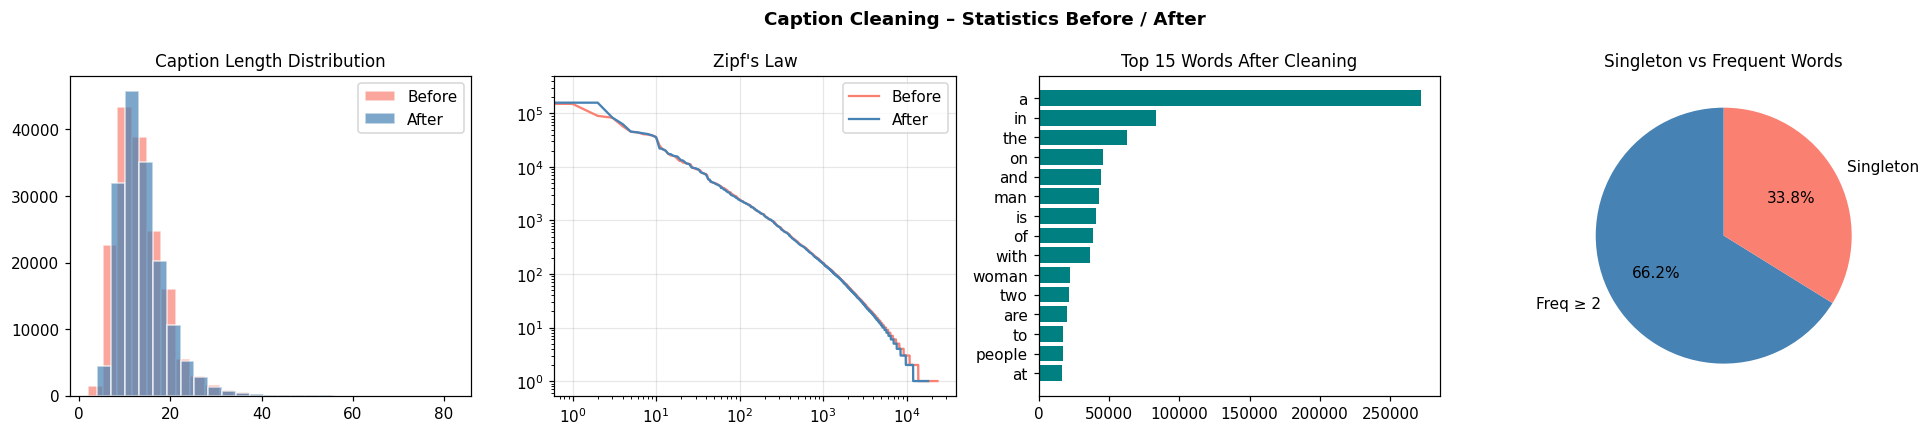

  ✅ Saved descriptions → /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/descriptions_flickr30k.txt


In [9]:
# ─── BƯỚC 1: THỐNG KÊ TRƯỚC KHI CLEAN ────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  CAPTION CLEANING")
print(SEP)

all_words_before = Counter()
all_len_before   = []
for caps in all_descriptions.values():
    for cap in caps:
        toks = cap.split()
        all_words_before.update(toks)
        all_len_before.append(len(toks))

print(f"  BEFORE CLEANING:")
print(f"    Vocab size     : {len(all_words_before):,}")
print(f"    Total tokens   : {sum(all_words_before.values()):,}")
print(f"    Avg cap length : {np.mean(all_len_before):.2f} words")

# ─── BƯỚC 2: HÀM CLEAN ────────────────────────────────────────────────────────
def clean_caption(caption: str) -> str:
    caption = caption.lower()
    caption = re.sub(r"[^a-z\s']", ' ', caption)
    tokens  = caption.split()
    tokens  = [t for t in tokens
               if len(t) >= 1
               and not any(c.isdigit() for c in t)]
    return ' '.join(tokens)

# ─── BƯỚC 3: THỰC HIỆN CLEAN ─────────────────────────────────────────────────
clean_descriptions = {}
for img_id, caps in all_descriptions.items():
    cleaned = []
    for cap in caps:
        c = clean_caption(cap)
        if c:
            cleaned.append(f"startseq {c} endseq")
    if cleaned:
        clean_descriptions[img_id] = cleaned

# ─── BƯỚC 4: THỐNG KÊ SAU ────────────────────────────────────────────────────
all_words_after = Counter()
all_len_after   = []
for caps in clean_descriptions.values():
    for cap in caps:
        toks = cap.split()
        all_words_after.update(toks)
        all_len_after.append(len(toks))

real_vocab = {w for w in all_words_after if w not in ('startseq','endseq')}
print(f"\n  AFTER CLEANING:")
print(f"    Vocab size     : {len(real_vocab):,}")
print(f"    Avg cap length : {np.mean(all_len_after):.2f} words (incl. startseq/endseq)")

# ─── BƯỚC 5: TRỰC QUAN ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Caption Cleaning – Statistics Before / After', fontweight='bold')

axes[0].hist(all_len_before, bins=25, color='salmon', edgecolor='white', alpha=0.7, label='Before')
axes[0].hist(all_len_after,  bins=25, color='steelblue', edgecolor='white', alpha=0.7, label='After')
axes[0].set_title('Caption Length Distribution'); axes[0].legend()

freq_before = sorted(all_words_before.values(), reverse=True)
freq_after  = sorted(all_words_after.values(), reverse=True)
axes[1].loglog(freq_before, color='salmon', label='Before')
axes[1].loglog(freq_after,  color='steelblue', label='After')
axes[1].set_title("Zipf's Law"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

top15 = [(w,c) for w,c in all_words_after.most_common(25)
         if w not in ('startseq','endseq')][:15]
axes[2].barh([w for w,_ in top15][::-1], [c for _,c in top15][::-1], color='teal')
axes[2].set_title('Top 15 Words After Cleaning')

singletons = sum(1 for c in all_words_after.values() if c == 1)
axes[3].pie([len(all_words_after)-singletons, singletons],
            labels=['Freq ≥ 2','Singleton'], autopct='%1.1f%%',
            colors=['steelblue','salmon'], startangle=90)
axes[3].set_title('Singleton vs Frequent Words')

plt.tight_layout(); plt.show()

# ─── BƯỚC 6: LƯU ──────────────────────────────────────────────────────────────
with open(DESC_PATH, 'w', encoding='utf-8') as f:
    for img_id, caps in clean_descriptions.items():
        for cap in caps:
            f.write(f"{img_id} {cap}\n")
print(f"  ✅ Saved descriptions → {DESC_PATH}")
print(SEP)


## Cell 10: Tokenization và GloVe Embeddings

**Mục đích:**
- Xây dựng từ điển (word→index) từ tập train
- Load GloVe pre-trained embeddings 300d
- Tạo embedding matrix khởi tạo cho model

**Lưu ý:** Tokenizer được lưu với prefix `clip_` riêng — không dùng chung với VGG16 để tránh nhầm lẫn vocab.

| Thành phần | Cấu hình |
|---|---|
| Vocab size | 10,000 từ phổ biến nhất trong tập train |
| Special tokens | `<pad>=0`, `<unk>=1`, `startseq=2`, `endseq=3` |
| Embeddings | GloVe 300d (~99% coverage), fallback random |


  TOKENIZATION & GLOVE EMBEDDINGS
  Train: 29,769 images, 148,844 captions
  Dev  : 1,014 images,  5,070 captions
  Test : 1,000 images,  5,000 captions

  Building vocabulary from training set...
  Vocab size: 10,000
  Special tokens: <pad>=0, <unk>=1, startseq=2, endseq=3
  MAX_LEN used: 35

  Searching for GloVe file...
  ✅ GloVe found: /Applications/Python_AI/Neural_Image_Caption_Generation/glove.6B.300d.txt


  Coverage: 9922/9999 = 99.2%
  EMBED_DIM used: 300d


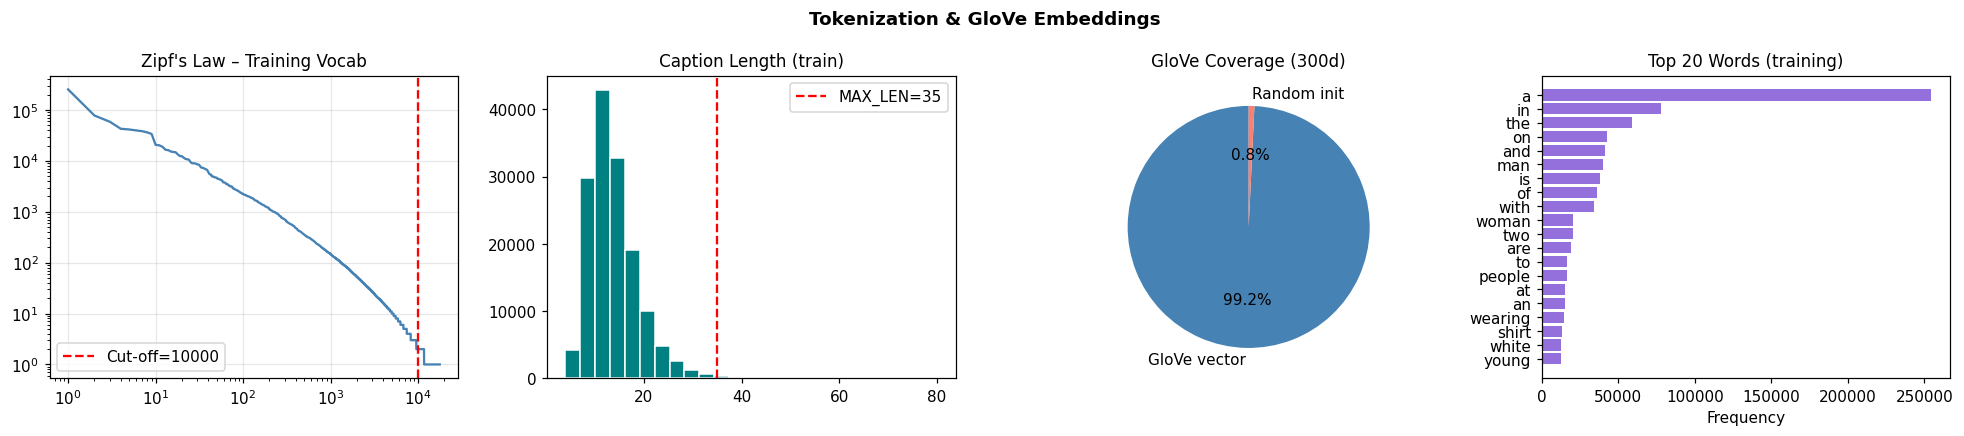

  ✅ Saved tokenizer → /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/tokenizer_clip_flickr30k.pkl


In [10]:
# ─── BƯỚC 1: TẢI SPLITS VÀ BUILD VOCAB ──────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  TOKENIZATION & GLOVE EMBEDDINGS")
print(SEP)

assert SPLITS_PATH.exists(), f"❌ Splits not found – re-run Cell 8"
with open(SPLITS_PATH) as f:
    splits = json.load(f)
train_ids = set(splits['train'])
dev_ids   = set(splits['val'])
test_ids  = set(splits['test'])

def load_split_descriptions(split_ids):
    return {img_id: caps for img_id, caps in clean_descriptions.items()
            if img_id in split_ids}

train_desc = load_split_descriptions(train_ids)
dev_desc   = load_split_descriptions(dev_ids)
test_desc  = load_split_descriptions(test_ids)

print(f"  Train: {len(train_desc):,} images, "
      f"{sum(len(v) for v in train_desc.values()):,} captions")
print(f"  Dev  : {len(dev_desc):,} images,  "
      f"{sum(len(v) for v in dev_desc.values()):,} captions")
print(f"  Test : {len(test_desc):,} images,  "
      f"{sum(len(v) for v in test_desc.values()):,} captions")

# ─── BƯỚC 2: XÂY DỰNG VOCAB ──────────────────────────────────────────────────
print(f"\n  Building vocabulary from training set...")
train_word_freq = Counter()
for caps in train_desc.values():
    for cap in caps:
        train_word_freq.update(cap.split())

SPECIAL = ['<pad>', '<unk>', 'startseq', 'endseq']
common_words    = [w for w,_ in train_word_freq.most_common()
                   if w not in SPECIAL]
vocab_words     = SPECIAL + common_words[:VOCAB_SIZE - len(SPECIAL)]
word2idx        = {w: i for i, w in enumerate(vocab_words)}
idx2word        = {i: w for i, w in enumerate(vocab_words)}
vocab_size_actual = len(vocab_words)

START_ID = word2idx['startseq']
END_ID   = word2idx['endseq']
PAD_ID   = word2idx['<pad>']
UNK_ID   = word2idx['<unk>']

print(f"  Vocab size: {vocab_size_actual:,}")
print(f"  Special tokens: <pad>={PAD_ID}, <unk>={UNK_ID}, "
      f"startseq={START_ID}, endseq={END_ID}")

all_train_lengths = [len(cap.split())
                     for caps in train_desc.values() for cap in caps]
MAX_LEN = min(max(all_train_lengths) + 1, MAX_LENGTH)
print(f"  MAX_LEN used: {MAX_LEN}")

# ─── BƯỚC 3: LOAD GLOVE ──────────────────────────────────────────────────────
print(f"\n  Searching for GloVe file...")
glove_path = None
for p in GLOVE_SEARCH_PATHS:
    if p.exists():
        glove_path = p; break

embedding_matrix = None
glove_dim        = EMBED_DIM
glove_coverage   = 0.0

if glove_path is not None:
    print(f"  ✅ GloVe found: {glove_path}")
    glove_index = {}
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, desc='Load GloVe', leave=False):
            vals = line.strip().split()
            if len(vals) >= 2:
                glove_index[vals[0]] = np.array(vals[1:], dtype='float32')

    glove_dim = len(next(iter(glove_index.values())))
    embedding_matrix = np.random.uniform(-0.1, 0.1,
                                         (vocab_size_actual, glove_dim)).astype('float32')
    embedding_matrix[PAD_ID] = 0.0
    hits = 0
    for word, idx in word2idx.items():
        if word in glove_index:
            embedding_matrix[idx] = glove_index[word]; hits += 1
    glove_coverage = hits / max(1, vocab_size_actual - 1)
    print(f"  Coverage: {hits}/{vocab_size_actual-1} = {glove_coverage:.1%}")
    del glove_index; gc.collect()
else:
    print("  ⚠️  GloVe not found – using random embeddings.")

EMBED_DIM = glove_dim
print(f"  EMBED_DIM used: {EMBED_DIM}d")

# ─── BƯỚC 4: TRỰC QUAN ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Tokenization & GloVe Embeddings', fontweight='bold')

freqs = [c for w,c in train_word_freq.most_common() if w not in SPECIAL]
axes[0].loglog(range(1, len(freqs)+1), freqs, color='steelblue')
axes[0].axvline(VOCAB_SIZE, color='red', linestyle='--', label=f'Cut-off={VOCAB_SIZE}')
axes[0].set_title("Zipf's Law – Training Vocab"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(all_train_lengths, bins=25, color='teal', edgecolor='white')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title('Caption Length (train)'); axes[1].legend()

if embedding_matrix is not None:
    axes[2].pie([int(glove_coverage*(vocab_size_actual-1)),
                 int((1-glove_coverage)*(vocab_size_actual-1))],
                labels=['GloVe vector','Random init'], autopct='%1.1f%%',
                colors=['steelblue','salmon'], startangle=90)
    axes[2].set_title(f'GloVe Coverage ({EMBED_DIM}d)')
else:
    axes[2].text(0.5, 0.5, 'GloVe not found', ha='center', va='center',
                 fontsize=14, transform=axes[2].transAxes)
    axes[2].set_title('GloVe Coverage')

top20 = [(w,c) for w,c in train_word_freq.most_common(25) if w not in SPECIAL][:20]
axes[3].barh([w for w,_ in top20][::-1], [c for _,c in top20][::-1], color='mediumpurple')
axes[3].set_title('Top 20 Words (training)'); axes[3].set_xlabel('Frequency')
plt.tight_layout(); plt.show()

# ─── BƯỚC 5: LƯU TOKENIZER ────────────────────────────────────────────────────
tokenizer_data = {
    'word2idx': word2idx, 'idx2word': idx2word,
    'vocab_size': vocab_size_actual, 'max_len': MAX_LEN,
    'embed_dim': EMBED_DIM, 'glove_coverage': glove_coverage,
}
with open(TOKENIZER_PATH, 'wb') as f:
    pickle.dump(tokenizer_data, f)
print(f"  ✅ Saved tokenizer → {TOKENIZER_PATH}")
print(SEP)


## Cell 11: Tạo Training Samples (PyTorch Dataset + DataLoader)

**Kỹ thuật Teacher Forcing:**
```
Caption:  startseq  a   dog  runs  on  grass  endseq
Input  :  startseq  a   dog  runs  on  grass          ← X_caption (seq len - 1)
Target :             a   dog  runs  on  grass  endseq  ← Y_target  (seq len - 1)
```

Mỗi sample = `(image_feature: (49,512), caption_input: (MAX_LEN-1,), target: (MAX_LEN-1,))`

**Đặc điểm:**
- Features load trực tiếp từ RAM dict (pkl đã load) → nhanh
- Padding `<pad>` ở cuối nếu caption ngắn hơn MAX_LEN
- DataLoader shuffle train, không shuffle val/test


In [11]:
# ─── BƯỚC 1: GIẢI THÍCH TEACHER FORCING ─────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  PYTORCH DATASET + DATALOADER")
print(SEP)

ex_cap = "startseq a dog runs on grass endseq"
ex_ids = [word2idx.get(w, UNK_ID) for w in ex_cap.split()]
print("  Teacher Forcing – Example:")
print(f"    Caption : {ex_cap}")
print(f"    Input   : {[idx2word.get(i,'?') for i in ex_ids[:-1]]}")
print(f"    Target  : {[idx2word.get(i,'?') for i in ex_ids[1:]]}")

# ─── BƯỚC 2: DATASET CLASS ────────────────────────────────────────────────────
class CaptionDataset(Dataset):
    """PyTorch Dataset for Image Captioning with Teacher Forcing."""

    def __init__(self, descriptions: Dict[str, List[str]],
                 features: Dict[str, np.ndarray],
                 word2idx: Dict[str, int], max_len: int):
        self.features = features
        self.max_len  = max_len
        unk = word2idx.get('<unk>', 1)
        pad = word2idx.get('<pad>', 0)
        self.samples: List[Tuple[str, np.ndarray, np.ndarray]] = []
        skipped = 0

        for img_id, caps in descriptions.items():
            if img_id not in features:
                skipped += 1; continue
            for cap in caps:
                ids = [word2idx.get(w, unk) for w in cap.split()]
                ids = ids[:max_len]
                ids += [pad] * (max_len - len(ids))
                self.samples.append((img_id,
                                     np.array(ids[:-1], dtype=np.int64),
                                     np.array(ids[1:],  dtype=np.int64)))
        if skipped:
            print(f"  ⚠️  {skipped} images skipped (no features)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_id, inp, tgt = self.samples[idx]
        feat = torch.FloatTensor(self.features[img_id])  # (49, 512)
        return feat, torch.LongTensor(inp), torch.LongTensor(tgt)


# ─── BƯỚC 3: FEATURES CHO TỪNG SPLIT ─────────────────────────────────────────
train_feat = {k: v for k, v in features_conv.items() if k in train_ids}
dev_feat   = {k: v for k, v in features_conv.items() if k in dev_ids}
test_feat  = {k: v for k, v in features_conv.items() if k in test_ids}

print(f"\n  Features per split:")
print(f"    Train: {len(train_feat):,} images")
print(f"    Dev  : {len(dev_feat):,} images")
print(f"    Test : {len(test_feat):,} images")

# ─── BƯỚC 4: DATALOADERS ──────────────────────────────────────────────────────
train_ds = CaptionDataset(train_desc, train_feat, word2idx, MAX_LEN)
dev_ds   = CaptionDataset(dev_desc,   dev_feat,   word2idx, MAX_LEN)
test_ds  = CaptionDataset(test_desc,  test_feat,  word2idx, MAX_LEN)

num_workers = 0  # 0 is safe for MPS; increase for CUDA/CPU if needed
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=num_workers, pin_memory=(device.type=='cuda'))
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers)

print(f"\n  Dataset sizes:")
print(f"    Train: {len(train_ds):,} samples  ({len(train_loader):,} batches)")
print(f"    Dev  : {len(dev_ds):,} samples  ({len(dev_loader):,} batches)")
print(f"    Test : {len(test_ds):,} samples  ({len(test_loader):,} batches)")

feat_b, inp_b, tgt_b = next(iter(train_loader))
print(f"\n  Batch shapes:")
print(f"    Features : {tuple(feat_b.shape)}   ← (B, 49, 512) CLIP patches")
print(f"    Input    : {tuple(inp_b.shape)}    ← (B, MAX_LEN-1) caption tokens")
print(f"    Target   : {tuple(tgt_b.shape)}    ← (B, MAX_LEN-1) shifted by 1")
print(SEP)


  PYTORCH DATASET + DATALOADER
  Teacher Forcing – Example:
    Caption : startseq a dog runs on grass endseq
    Input   : ['startseq', 'a', 'dog', 'runs', 'on', 'grass']
    Target  : ['a', 'dog', 'runs', 'on', 'grass', 'endseq']

  Features per split:
    Train: 29,769 images
    Dev  : 1,014 images
    Test : 1,000 images

  Dataset sizes:
    Train: 148,844 samples  (2,326 batches)
    Dev  : 5,070 samples  (80 batches)
    Test : 5,000 samples  (79 batches)

  Batch shapes:
    Features : (64, 49, 512)   ← (B, 49, 512) CLIP patches
    Input    : (64, 34)    ← (B, MAX_LEN-1) caption tokens
    Target   : (64, 34)    ← (B, MAX_LEN-1) shifted by 1


## Cell 12: Xây dựng Kiến trúc Model

**Mục đích:** Định nghĩa kiến trúc **LSTM Decoder với Bahdanau Attention** nhận đặc trưng từ CLIP.

### Kiến trúc Tổng thể

```
CLIP ViT-B/32 features (B, 49, 512)    ← frozen, đã trích xuất
       │
       ├──► Init hidden : Linear(512→512) tanh ──► h₀
       ├──► Init cell   : Linear(512→512) tanh ──► c₀
       │
       ▼
  BahdanauAttention(hidden, features)
       │  score(h, fᵢ) = V·tanh(Wₕ·h + W_f·fᵢ)   [49 regions]
       │  α = softmax(scores)
       │  context = Σ αᵢ·fᵢ                        (512)
       ▼
  LSTM input = [word_embed(300) ‖ context(512)]     (812)
       │
       ▼
  LSTMCell(812 → hidden=512)
       │
       ▼
  Linear(512 → vocab=10,000)  →  softmax → next word
```

**Decoder không thay đổi so với VGG16** vì feature shape giống nhau `(49, 512)`.


In [12]:
# ─── ĐỊNH NGHĨA CÁC CLASS ────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  MODEL ARCHITECTURE – CLIP ViT-B/32 + Bahdanau Attention")
print(SEP)


class BahdanauAttention(nn.Module):
    """Additive (Bahdanau) Attention.
    Score(h, f_i) = V · tanh(W_h·h + W_f·f_i)
    α = softmax(scores)
    context = Σ αᵢ · fᵢ
    """
    def __init__(self, hidden_size: int, feature_size: int):
        super().__init__()
        self.W_h = nn.Linear(hidden_size,  hidden_size, bias=False)
        self.W_f = nn.Linear(feature_size, hidden_size, bias=False)
        self.V   = nn.Linear(hidden_size,  1,           bias=False)

    def forward(self, hidden: torch.Tensor, features: torch.Tensor):
        h_exp    = self.W_h(hidden).unsqueeze(1)       # (B, 1, H)
        f_proj   = self.W_f(features)                  # (B, 49, H)
        energy   = self.V(torch.tanh(h_exp + f_proj))  # (B, 49, 1)
        weights  = torch.softmax(energy, dim=1)         # (B, 49, 1)
        context  = (weights * features).sum(dim=1)     # (B, 512)
        return context, weights.squeeze(-1)


class CaptionDecoder(nn.Module):
    """LSTM Decoder with Bahdanau Attention for Image Captioning.
    Nhận CLIP ViT-B/32 patch features (B, 49, 512).
    """
    def __init__(self, vocab_size: int, embed_dim: int, hidden_size: int,
                 feature_size: int = 512, dropout: float = 0.5,
                 embedding_matrix: Optional[np.ndarray] = None,
                 embed_trainable: bool = True):
        super().__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_ID)
        if embedding_matrix is not None:
            self.embedding.weight = nn.Parameter(
                torch.FloatTensor(embedding_matrix), requires_grad=embed_trainable)

        self.attention = BahdanauAttention(hidden_size, feature_size)
        self.lstm      = nn.LSTM(embed_dim + feature_size, hidden_size, batch_first=True)
        self.init_h    = nn.Linear(feature_size, hidden_size)
        self.init_c    = nn.Linear(feature_size, hidden_size)
        self.dropout   = nn.Dropout(dropout)
        self.fc_out    = nn.Linear(hidden_size, vocab_size)

    def _init_hidden(self, features: torch.Tensor):
        mean_feat = features.mean(dim=1)
        h = torch.tanh(self.init_h(mean_feat)).unsqueeze(0)   # (1, B, H)
        c = torch.tanh(self.init_c(mean_feat)).unsqueeze(0)   # (1, B, H)
        return h, c

    def forward(self, features: torch.Tensor, captions: torch.Tensor):
        emb  = self.dropout(self.embedding(captions))         # (B, T, E)
        h, c = self._init_hidden(features)
        logits = []
        for t in range(captions.size(1)):
            h_t         = h.squeeze(0)                        # (B, H)
            context, _  = self.attention(h_t, features)       # (B, 512)
            lstm_in     = torch.cat([emb[:,t,:], context], dim=1).unsqueeze(1)
            out, (h, c) = self.lstm(lstm_in, (h, c))          # (B, 1, H)
            logit       = self.fc_out(self.dropout(out.squeeze(1)))
            logits.append(logit)
        return torch.stack(logits, dim=1)                     # (B, T, V)

    @torch.no_grad()
    def generate_beam(self, features: torch.Tensor, beam_width: int = 5,
                      max_len: int = 35) -> str:
        self.eval()
        h0, c0    = self._init_hidden(features)
        beams     = [(0.0, [START_ID], h0, c0)]
        completed = []

        for _ in range(max_len):
            candidates = []
            for score, tokens, bh, bc in beams:
                if tokens[-1] == END_ID:
                    completed.append((score / len(tokens), tokens)); continue
                last_t  = torch.tensor([[tokens[-1]]], dtype=torch.long, device=features.device)
                emb     = self.embedding(last_t)
                ctx, _  = self.attention(bh.squeeze(0), features)
                inp_t   = torch.cat([emb.squeeze(1), ctx], dim=1).unsqueeze(1)
                out, (new_h, new_c) = self.lstm(inp_t, (bh, bc))
                log_p   = F.log_softmax(self.fc_out(out.squeeze(1)), dim=-1)
                topk    = torch.topk(log_p, beam_width, dim=-1)
                for i in range(beam_width):
                    tok    = topk.indices[0, i].item()
                    new_sc = score + topk.values[0, i].item()
                    candidates.append((new_sc, tokens + [tok], new_h, new_c))

            if not candidates:
                break
            candidates.sort(key=lambda x: x[0]/len(x[1]), reverse=True)
            beams = candidates[:beam_width]

        for score, tokens, bh, bc in beams:
            completed.append((score / len(tokens), tokens))

        if not completed:
            return ''
        _, best = max(completed, key=lambda x: x[0])
        words = [idx2word.get(t,'')
                 for t in best
                 if t not in (START_ID, END_ID, PAD_ID, UNK_ID)
                 and idx2word.get(t,'')]
        return ' '.join(words)


# ─── TẠO MODEL ────────────────────────────────────────────────────────────────
model = CaptionDecoder(
    vocab_size       = vocab_size_actual,
    embed_dim        = EMBED_DIM,
    hidden_size      = HIDDEN_SIZE,
    feature_size     = FEATURE_SIZE,
    dropout          = DROPOUT,
    embedding_matrix = embedding_matrix,
    embed_trainable  = EMBED_TRAINABLE,
).to(device)

total_p   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n  MODEL: CaptionDecoder (CLIP features + LSTM-{HIDDEN_SIZE} + Bahdanau Attention)")
print(f"  {'Layer':<40} {'Shape':<20} {'Status'}")
print(f"  {'-'*72}")
for name, param in model.named_parameters():
    flag = 'trainable' if param.requires_grad else 'frozen'
    print(f"  {name:<40} {str(tuple(param.shape)):<20} ({flag})")
print(f"\n  Total params   : {total_p:,}")
print(f"  Trainable      : {trainable:,}")
print(f"  Non-trainable  : {total_p - trainable:,}")

# Test forward pass
with torch.no_grad():
    out_t = model(feat_b[:4].to(device), inp_b[:4].to(device))
print(f"\n  Test forward pass:")
print(f"    Input features : {tuple(feat_b[:4].shape)}")
print(f"    Output logits  : {tuple(out_t.shape)}  ← (B, T, vocab)")

# Save architecture
arch_info = {
    'encoder'         : 'CLIP ViT-B/32',
    'vocab_size'      : vocab_size_actual,
    'embed_dim'       : EMBED_DIM,
    'hidden_size'     : HIDDEN_SIZE,
    'feature_size'    : FEATURE_SIZE,
    'num_regions'     : NUM_REGIONS,
    'dropout'         : DROPOUT,
    'total_params'    : total_p,
    'trainable_params': trainable,
}
with open(MODEL_DIR / 'model_architecture_clip.json', 'w') as f:
    json.dump(arch_info, f, indent=2)
print(f"  ✅ Saved arch info → {MODEL_DIR / 'model_architecture_clip.json'}")
print(SEP)


  MODEL ARCHITECTURE – CLIP ViT-B/32 + Bahdanau Attention

  MODEL: CaptionDecoder (CLIP features + LSTM-512 + Bahdanau Attention)
  Layer                                    Shape                Status
  ------------------------------------------------------------------------
  embedding.weight                         (10000, 300)         (trainable)
  attention.W_h.weight                     (512, 512)           (trainable)
  attention.W_f.weight                     (512, 512)           (trainable)
  attention.V.weight                       (1, 512)             (trainable)
  lstm.weight_ih_l0                        (2048, 812)          (trainable)
  lstm.weight_hh_l0                        (2048, 512)          (trainable)
  lstm.bias_ih_l0                          (2048,)              (trainable)
  lstm.bias_hh_l0                          (2048,)              (trainable)
  init_h.weight                            (512, 512)           (trainable)
  init_h.bias                          

## Cell 13: Huấn luyện Model

**Mục đích:** Train model 10 epoch, theo dõi validation loss, lưu checkpoint tốt nhất.

| Thành phần | Cấu hình |
|---|---|
| Loss | `CrossEntropyLoss(ignore_index=<pad>, label_smoothing=0.1)` |
| Optimizer | `AdamW(lr=1e-4, weight_decay=1e-4)` |
| Scheduler | `ReduceLROnPlateau(factor=0.5, patience=2)` |
| Early stop | patience=5 |
| **Epochs** | **10** |

**Tại sao chỉ 10 epochs?**
- CLIP features đã mạnh → model hội tụ nhanh hơn VGG16
- Quick experiment để so sánh BLEU với VGG16/ResNet
- Set `EPOCHS=50` nếu muốn train đầy đủ

**Checkpoint:** Chỉ lưu epoch có val_loss tốt nhất → `caption_clip_flickr30k_best.pt`


  MODEL TRAINING – CLIP ViT-B/32
  Device     : Apple MPS (GPU) ✅
  Epochs     : 10
  Steps/epoch: 2,326
  Loss       : CrossEntropyLoss(ignore_index=0, ls=0.1)
  Optimizer  : AdamW(lr=0.0001, wd=0.0001)
  Scheduler  : ReduceLROnPlateau(factor=0.5, patience=2)

  Starting training on Apple MPS (GPU) ✅...
    Epoch | TrainLoss | TrainAcc | ValLoss | ValAcc |       LR | Time
  ------------------------------------------------------------------------
    [2325/2326] loss 5.4208 | acc 24.8%
  Epoch 01/10 | 5.4206 / 24.8% | 4.8027 / 30.3% | 1.00e-04 | 609s ✅
    [2325/2326] loss 4.7652 | acc 30.9%
  Epoch 02/10 | 4.7651 / 30.9% | 4.4603 / 33.8% | 1.00e-04 | 602s ✅
    [2325/2326] loss 4.5195 | acc 33.2%
  Epoch 03/10 | 4.5195 / 33.2% | 4.2786 / 35.4% | 1.00e-04 | 603s ✅
    [2325/2326] loss 4.3760 | acc 34.6%
  Epoch 04/10 | 4.3760 / 34.6% | 4.1676 / 36.7% | 1.00e-04 | 600s ✅
    [2325/2326] loss 4.2770 | acc 35.6%
  Epoch 05/10 | 4.2770 / 35.6% | 4.0865 / 37.6% | 1.00e-04 | 604s ✅
    [2325

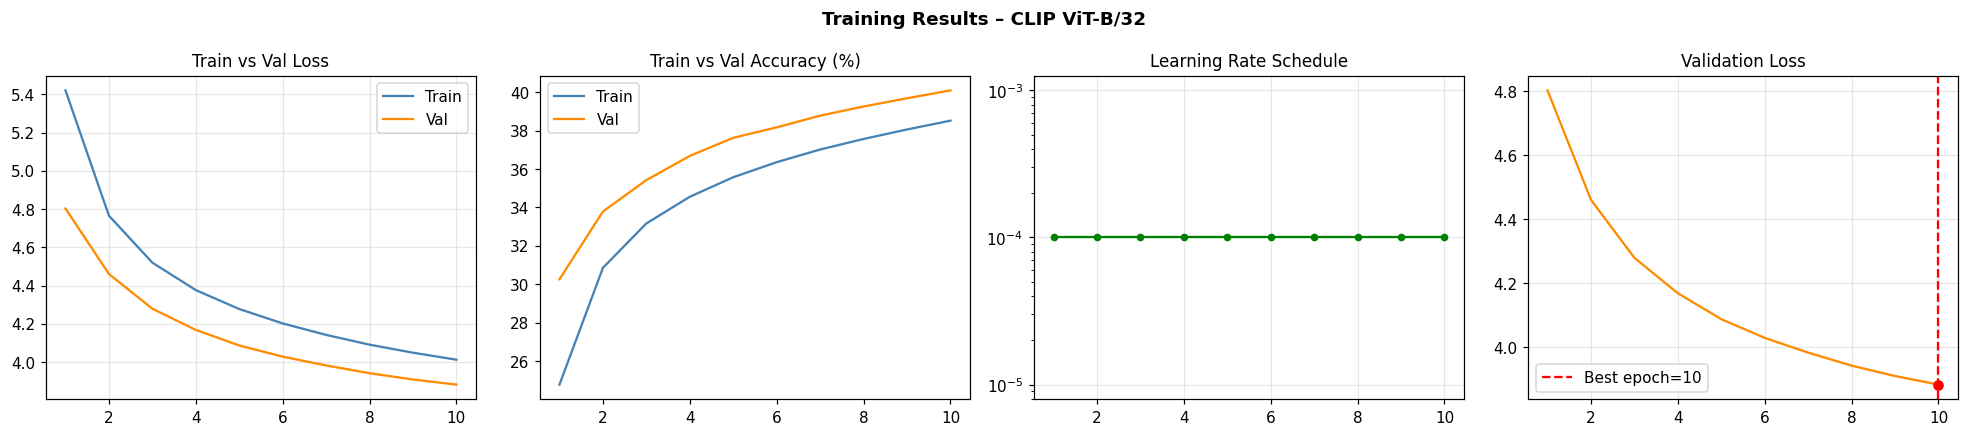

  Total epochs ran : 10
  Best val_loss    : 3.8817  (epoch 10)


In [13]:
# ─── CẤU HÌNH TRAINING ────────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  MODEL TRAINING – CLIP ViT-B/32")
print(SEP)

if device.type == 'mps':
    device_label = 'Apple MPS (GPU) ✅'
elif device.type == 'cuda':
    device_label = f'CUDA GPU — {torch.cuda.get_device_name(0)} ✅'
else:
    device_label = 'CPU ❌'

print(f"  Device     : {device_label}")
print(f"  Epochs     : {EPOCHS}")
print(f"  Steps/epoch: {len(train_loader):,}")

criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=LABEL_SMOOTHING)
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR,
                              patience=LR_PATIENCE)

print(f"  Loss       : CrossEntropyLoss(ignore_index={PAD_ID}, ls={LABEL_SMOOTHING})")
print(f"  Optimizer  : AdamW(lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"  Scheduler  : ReduceLROnPlateau(factor={LR_FACTOR}, patience={LR_PATIENCE})")

# ─── TRAINING LOOP ────────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}
best_val_loss = float('inf')
patience_ctr  = 0


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_correct, total_tokens, total_n = 0.0, 0, 0, 0
    n_steps   = len(loader)
    log_every = max(1, n_steps // 5)

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for step, (feat, inp, tgt) in enumerate(loader, 1):
            feat = feat.to(device)
            inp  = inp.to(device)
            tgt  = tgt.to(device)
            logits = model(feat, inp)                      # (B, T, V)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B*T, V), tgt.reshape(B*T))

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            with torch.no_grad():
                pred = logits.argmax(dim=-1)
                mask = tgt != PAD_ID
                total_correct += ((pred == tgt) & mask).sum().item()
                total_tokens  += mask.sum().item()

            total_loss += loss.item() * B
            total_n    += B

            if train and step % log_every == 0:
                running_acc = total_correct / max(total_tokens, 1) * 100
                print(f"\r    [{step:>4}/{n_steps}] loss {total_loss/total_n:.4f} | "
                      f"acc {running_acc:.1f}%", end='', flush=True)

    if train:
        print()
    return total_loss / max(total_n, 1), total_correct / max(total_tokens, 1) * 100


if MODEL_PATH.exists() and not FORCE_RETRAIN:
    print(f"\n  ✅ Checkpoint found, loading...")
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    if HISTORY_PATH.exists():
        with open(HISTORY_PATH) as f:
            history = json.load(f)
    best_val_loss = min(history.get('val_loss', [float('inf')]))
    print(f"  Best val_loss from checkpoint: {best_val_loss:.4f}")
else:
    print(f"\n  Starting training on {device_label}...")
    print(f"  {'Epoch':>7} | {'TrainLoss':>9} | {'TrainAcc':>8} | "
          f"{'ValLoss':>7} | {'ValAcc':>6} | {'LR':>8} | Time")
    print(f"  {'-'*72}")

    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = run_epoch(train_loader, train=True)
        val_loss,   val_acc   = run_epoch(dev_loader,   train=False)
        elapsed    = time.time() - t0
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        improved = val_loss < best_val_loss
        flag = ' ✅' if improved else f' (p {patience_ctr+1}/{EARLY_STOP_PATIENCE})'
        print(f"  Epoch {epoch:02d}/{EPOCHS} | "
              f"{train_loss:.4f} / {train_acc:.1f}% | "
              f"{val_loss:.4f} / {val_acc:.1f}% | "
              f"{current_lr:.2e} | {elapsed:.0f}s{flag}")

        scheduler.step(val_loss)

        if improved:
            best_val_loss = val_loss
            patience_ctr  = 0
            torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                        'val_loss': val_loss, 'optimizer_state': optimizer.state_dict()},
                       MODEL_PATH)
        else:
            patience_ctr += 1
            if patience_ctr >= EARLY_STOP_PATIENCE:
                print(f"    ⏹  Early stopping at epoch {epoch}")
                break

    with open(HISTORY_PATH, 'w') as f:
        json.dump(history, f)
    print(f"\n  ✅ Training complete. Best val_loss = {best_val_loss:.4f}")

# ─── TRỰC QUAN KẾT QUẢ TRAINING ──────────────────────────────────────────────
if len(history['train_loss']) > 0:
    epochs_ran = list(range(1, len(history['train_loss']) + 1))
    fig, axes  = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle('Training Results – CLIP ViT-B/32', fontweight='bold')

    axes[0].plot(epochs_ran, history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   color='darkorange')
    axes[0].set_title('Train vs Val Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

    if history.get('train_acc'):
        axes[1].plot(epochs_ran, history['train_acc'], label='Train', color='steelblue')
        axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   color='darkorange')
        axes[1].set_title('Train vs Val Accuracy (%)'); axes[1].legend()
    else:
        axes[1].set_visible(False)

    axes[2].plot(epochs_ran, history['lr'], color='green', marker='o', markersize=4)
    axes[2].set_title('Learning Rate Schedule'); axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)

    best_ep = history['val_loss'].index(min(history['val_loss'])) + 1
    axes[3].plot(epochs_ran, history['val_loss'], color='darkorange')
    axes[3].axvline(best_ep, color='red', linestyle='--', label=f'Best epoch={best_ep}')
    axes[3].scatter([best_ep], [min(history['val_loss'])], color='red', zorder=5)
    axes[3].set_title('Validation Loss'); axes[3].legend(); axes[3].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()
    print(f"  Total epochs ran : {len(epochs_ran)}")
    print(f"  Best val_loss    : {min(history['val_loss']):.4f}  (epoch {best_ep})")
print(SEP)


## Cell 14: Đánh giá Model với BLEU Score

**Mục đích:** Đánh giá khách quan chất lượng model trên tập test.

**BLEU Score:**
- Đo lường độ trùng khớp n-gram giữa caption sinh ra và reference captions
- **BLEU-4 là chỉ số chính** trong image captioning

**So sánh baseline:**
| Model | Dataset | BLEU-4 |
|---|---|---|
| Flickr8k VGG16 (Keras) | Flickr8k | 0.1186 |
| VGG16 (PyTorch, 50ep) | Flickr30k | *(kết quả của bạn)* |
| ResNet-101 (PyTorch, 50ep) | Flickr30k | *(kết quả của bạn)* |
| **CLIP ViT-B/32 (10ep)** | **Flickr30k** | **← bạn đang đo** |

**Kỳ vọng:** CLIP features tốt hơn VGG16 → BLEU cao hơn dù chỉ train 10 epoch.


  BLEU SCORE EVALUATION – CLIP ViT-B/32
  ✅ Loaded: epoch=10, val_loss=3.8817
  Generating captions for 1,000 test images (beam=5)...


Evaluating: 100%|██████████| 1000/1000 [05:54<00:00,  2.82it/s]



  ╔════════════════════════════════════════════╗
  ║  EVALUATION RESULTS – CLIP ViT-B/32        ║
  ╠════════════════════════════════════════════╣
  ║  BLEU-1 : 0.6598                              ║
  ║  BLEU-2 : 0.4830                              ║
  ║  BLEU-3 : 0.3443                              ║
  ║  BLEU-4 : 0.2433   ← main metric              ║
  ╠════════════════════════════════════════════╣
  ║  Flickr8k Baseline BLEU-4 : 0.1186          ║
  ║  (khác dataset, chỉ tham khảo)               ║
  ╚════════════════════════════════════════════╝

  BLEU-4 per image:
    Mean  : 0.2183
    Median: 0.1472
    Min   : 0.0137  Max: 1.0000


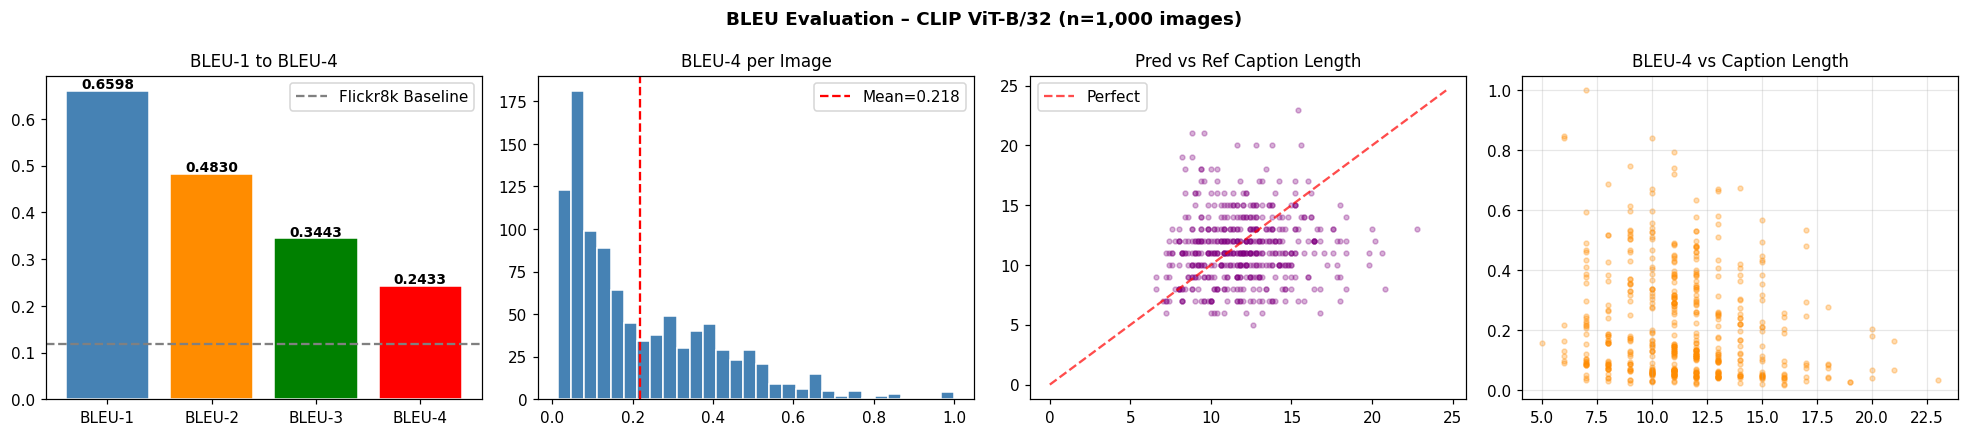

  ✅ Saved → /Applications/Python_AI/Neural_Image_Caption_Generation/workspace/models/evaluation_results_clip.json


In [14]:
# ─── LOAD BEST MODEL ─────────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  BLEU SCORE EVALUATION – CLIP ViT-B/32")
print(SEP)

if MODEL_PATH.exists():
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
    _ep  = checkpoint.get('epoch', '?')
    _vl  = checkpoint.get('val_loss', None)
    _vls = f"{_vl:.4f}" if _vl is not None else "?"
    print(f"  ✅ Loaded: epoch={_ep}, val_loss={_vls}")
else:
    print("  ⚠️  Checkpoint not found, using current model.")

model.eval()
smooth_fn     = SmoothingFunction().method1
actual_refs   = []
predicted     = []
per_img_bleu4 = []

print(f"  Generating captions for {len(test_desc):,} test images (beam={BEAM_WIDTH})...")
with torch.no_grad():
    for img_id, refs in tqdm(test_desc.items(), desc='Evaluating'):
        if img_id not in test_feat:
            continue
        feat    = torch.FloatTensor(test_feat[img_id]).unsqueeze(0).to(device)
        caption = model.generate_beam(feat, beam_width=BEAM_WIDTH, max_len=MAX_LEN)
        pred_tokens = caption.split()

        ref_list = [[w for w in ref.split() if w not in ('startseq','endseq')]
                    for ref in refs]
        actual_refs.append(ref_list)
        predicted.append(pred_tokens)
        per_img_bleu4.append(
            sentence_bleu(ref_list, pred_tokens,
                          weights=(0.25,0.25,0.25,0.25),
                          smoothing_function=smooth_fn))

# ─── TÍNH BLEU ────────────────────────────────────────────────────────────────
bleu1 = corpus_bleu(actual_refs, predicted, weights=(1,0,0,0))
bleu2 = corpus_bleu(actual_refs, predicted, weights=(0.5,0.5,0,0))
bleu3 = corpus_bleu(actual_refs, predicted, weights=(1/3,1/3,1/3,0))
bleu4 = corpus_bleu(actual_refs, predicted, weights=(0.25,0.25,0.25,0.25))

print(f"\n  ╔{'═'*44}╗")
print(f"  ║  EVALUATION RESULTS – CLIP ViT-B/32        ║")
print(f"  ╠{'═'*44}╣")
print(f"  ║  BLEU-1 : {bleu1:.4f}                              ║")
print(f"  ║  BLEU-2 : {bleu2:.4f}                              ║")
print(f"  ║  BLEU-3 : {bleu3:.4f}                              ║")
print(f"  ║  BLEU-4 : {bleu4:.4f}   ← main metric              ║")
print(f"  ╠{'═'*44}╣")
print(f"  ║  Flickr8k Baseline BLEU-4 : 0.1186          ║")
print(f"  ║  (khác dataset, chỉ tham khảo)               ║")
print(f"  ╚{'═'*44}╝")

print(f"\n  BLEU-4 per image:")
print(f"    Mean  : {np.mean(per_img_bleu4):.4f}")
print(f"    Median: {np.median(per_img_bleu4):.4f}")
print(f"    Min   : {min(per_img_bleu4):.4f}  Max: {max(per_img_bleu4):.4f}")

# ─── TRỰC QUAN ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f'BLEU Evaluation – CLIP ViT-B/32 (n={len(predicted):,} images)',
             fontweight='bold')

bleu_names = ['BLEU-1','BLEU-2','BLEU-3','BLEU-4']
bleu_vals  = [bleu1, bleu2, bleu3, bleu4]
colors     = ['steelblue','darkorange','green','red']
bars = axes[0].bar(bleu_names, bleu_vals, color=colors, edgecolor='white')
axes[0].axhline(0.1186, color='gray', linestyle='--', label='Flickr8k Baseline')
for bar, val in zip(bars, bleu_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('BLEU-1 to BLEU-4'); axes[0].legend()

axes[1].hist(per_img_bleu4, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(np.mean(per_img_bleu4), color='red', linestyle='--',
                label=f'Mean={np.mean(per_img_bleu4):.3f}')
axes[1].set_title('BLEU-4 per Image'); axes[1].legend()

pred_lengths = [len(p) for p in predicted]
ref_lengths  = [np.mean([len(r) for r in refs]) for refs in actual_refs]
axes[2].scatter(ref_lengths[:500], pred_lengths[:500], alpha=0.3, s=10, color='purple')
axes[2].plot([0, max(ref_lengths)], [0, max(ref_lengths)], 'r--', alpha=0.7, label='Perfect')
axes[2].set_title('Pred vs Ref Caption Length'); axes[2].legend()

axes[3].scatter(pred_lengths[:500], per_img_bleu4[:500], alpha=0.3, s=10, color='darkorange')
axes[3].set_title('BLEU-4 vs Caption Length'); axes[3].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

eval_results = {'encoder': 'CLIP ViT-B/32', 'epochs': EPOCHS,
                'bleu1': bleu1, 'bleu2': bleu2, 'bleu3': bleu3, 'bleu4': bleu4,
                'n_images': len(predicted), 'beam_width': BEAM_WIDTH}
with open(MODEL_DIR / 'evaluation_results_clip.json', 'w') as f:
    json.dump(eval_results, f, indent=2)
print(f"  ✅ Saved → {MODEL_DIR / 'evaluation_results_clip.json'}")
print(SEP)


## Cell 15: Demo – Sinh Caption cho Ảnh Mới

**Mục đích:**
- Demo sinh caption cho 4 ảnh test ngẫu nhiên
- So sánh caption sinh ra vs. reference captions
- Test với ảnh tùy chọn ngoài dataset

**Hàm `extract_single_image_feature`:**
- Tải lại CLIP model chỉ để extract 1 ảnh mới
- Dùng cùng pipeline patch-token như Cell 7
- Trả về tensor `(1, 49, 512)` để đưa vào decoder


  DEMO – CAPTION GENERATION (CLIP ViT-B/32)
  Generating captions for 4 random test images...

  [313542438]
    Generated : two asian women are sitting at a table in a restaurant
    Ref[0]    : two asian women are sitting at a table enjoying their foods

  [2178295140]
    Generated : a group of people are standing in front of a store
    Ref[0]    : a man with shoulder length brown hair is smoking a cigarette outside while wearing a black jacket and blue jeans

  [2772831016]
    Generated : a group of men dressed in black and white uniforms are standing in front of a crowd
    Ref[0]    : five people dressed in military uniform are holding guns in front of their face

  [199412398]
    Generated : a group of people are walking down the street
    Ref[0]    : a boy surveys merchandise in an alleyway market


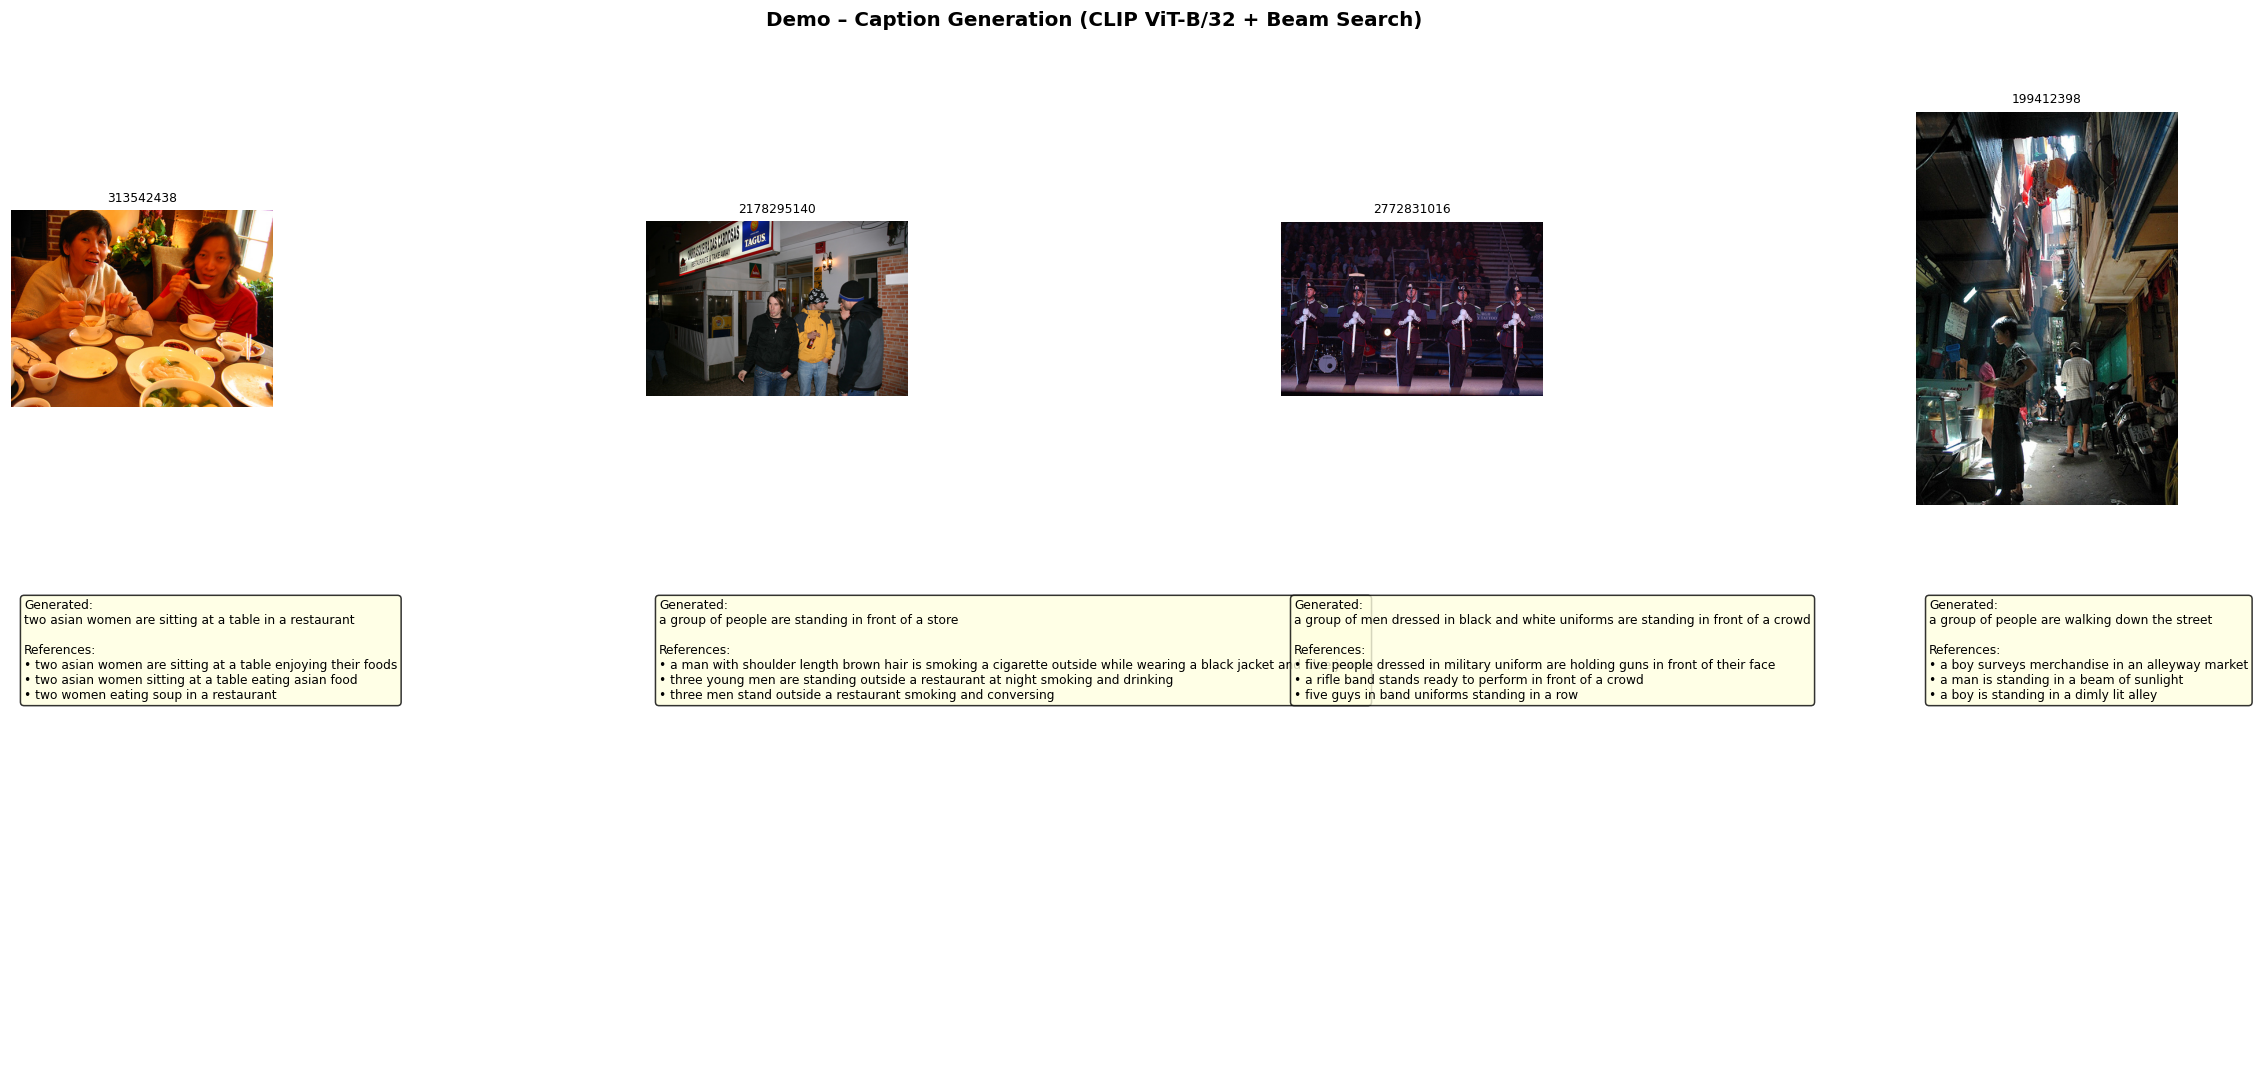


  DETAILED ANALYSIS – 10 TEST IMAGES
  1107246521             BLEU-4=0.067 | a black and white dog is running through the grass
  47951611               BLEU-4=0.128 | two men in orange vests are standing in front of a body of w
  3197960343             BLEU-4=0.252 | a man in a blue shirt is holding a piece of paper
  2194797921             BLEU-4=0.040 | a woman in a white shirt and a woman in a white shirt are st
  2844018783             BLEU-4=0.089 | a young boy and a young boy are sitting on the floor in fron
  4587229099             BLEU-4=0.067 | two women are sitting on a bench in front of a building
  3221128704             BLEU-4=0.157 | a soccer player in a white uniform is kicking a soccer ball
  3575947093             BLEU-4=0.163 | a man in a black shirt is playing a piano
  6407653987             BLEU-4=0.062 | a group of young boys playing soccer
  406642021              BLEU-4=0.595 | a man in a blue shirt is climbing a rock

  CUSTOM IMAGE TEST (OPTIONAL)
  Set CUST

In [15]:
# ─── LOAD MODEL ──────────────────────────────────────────────────────────────
SEP = "=" * 65
print(SEP)
print("  DEMO – CAPTION GENERATION (CLIP ViT-B/32)")
print(SEP)

if MODEL_PATH.exists():
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state'])
model.eval()

# Hàm extract feature cho ảnh mới (ngoài dataset)
def extract_single_image_feature(img_path: Path) -> torch.Tensor:
    """Load CLIP, extract (49, 512) features cho 1 ảnh mới."""
    clip_t, _ = clip.load(CLIP_MODEL_NAME, device=device)
    clip_t = clip_t.float()   # float32 for MPS
    clip_t.eval()
    for p in clip_t.parameters():
        p.requires_grad = False

    clip_tfm = transforms.Compose([
        transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.48145466, 0.4578275,  0.40821073],
                             std =[0.26862954, 0.26130258, 0.27577711]),
    ])

    vit = clip_t.visual
    img    = Image.open(img_path).convert('RGB')
    tensor = clip_tfm(img).unsqueeze(0).to(device)      # (1, 3, 224, 224)

    with torch.no_grad():
        x = vit.conv1(tensor)
        B, D, H, W = x.shape
        x = x.reshape(B, D, H*W).permute(0, 2, 1)
        cls = vit.class_embedding.unsqueeze(0).unsqueeze(0).expand(B,-1,-1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + vit.positional_embedding.unsqueeze(0)
        x   = vit.ln_pre(x)
        x   = x.permute(1, 0, 2)
        x   = vit.transformer(x)
        x   = x.permute(1, 0, 2)
        patches = x[:, 1:, :]
        patches = vit.ln_post(patches)
        if vit.proj is not None:
            patches = patches @ vit.proj
    feat = patches.float()                               # (1, 49, 512)
    del clip_t; gc.collect()
    return feat

def generate_caption(img_id_or_path, beam_width=BEAM_WIDTH):
    if isinstance(img_id_or_path, str) and img_id_or_path in features_conv:
        feat = torch.FloatTensor(features_conv[img_id_or_path]).unsqueeze(0).to(device)
    else:
        feat = extract_single_image_feature(Path(img_id_or_path)).to(device)
    return model.generate_beam(feat, beam_width=beam_width, max_len=MAX_LEN)

# ─── HIỂN THỊ 4 ẢNH TEST ─────────────────────────────────────────────────────
print("  Generating captions for 4 random test images...")
sample_test_ids = random.sample(list(test_desc.keys()), min(4, len(test_desc)))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Demo – Caption Generation (CLIP ViT-B/32 + Beam Search)',
             fontsize=13, fontweight='bold')

for col, img_id in enumerate(sample_test_ids):
    img_path = IMAGE_DIR / f"{img_id}.jpg"
    if img_path.exists():
        axes[0, col].imshow(Image.open(img_path).convert('RGB'))
    axes[0, col].axis('off')
    axes[0, col].set_title(img_id[:15], fontsize=8)

    generated = generate_caption(img_id)
    refs = [' '.join(w for w in cap.split() if w not in ('startseq','endseq'))
            for cap in test_desc[img_id]]

    text  = f"Generated:\n{generated}\n\nReferences:\n"
    text += "\n".join(f"• {r}" for r in refs[:3])
    axes[1, col].text(0.05, 0.95, text, transform=axes[1, col].transAxes,
                      fontsize=8, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    axes[1, col].axis('off')
    print(f"\n  [{img_id}]")
    print(f"    Generated : {generated}")
    print(f"    Ref[0]    : {refs[0]}")

plt.tight_layout(); plt.show()

# ─── PHÂN TÍCH CHI TIẾT 10 ẢNH ────────────────────────────────────────────────
print(f"\n{SEP}")
print("  DETAILED ANALYSIS – 10 TEST IMAGES")
print(SEP)

for img_id in random.sample(list(test_desc.keys()), min(10, len(test_desc))):
    gen   = generate_caption(img_id)
    refs  = [' '.join(w for w in cap.split() if w not in ('startseq','endseq'))
             for cap in test_desc[img_id]]
    b4 = sentence_bleu([r.split() for r in refs], gen.split(),
                       weights=(0.25,0.25,0.25,0.25),
                       smoothing_function=SmoothingFunction().method1)
    print(f"  {img_id[:20]:<22} BLEU-4={b4:.3f} | {gen[:60]}")

# ─── TEST VỚI ẢNH TÙY CHỌN ────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  CUSTOM IMAGE TEST (OPTIONAL)")
print(SEP)
CUSTOM_IMAGE_PATH = ''   # ← Đặt đường dẫn ảnh của bạn ở đây, vd: '/path/to/dog.jpg'
if CUSTOM_IMAGE_PATH and Path(CUSTOM_IMAGE_PATH).exists():
    custom_cap = generate_caption(CUSTOM_IMAGE_PATH)
    print(f"  Image  : {CUSTOM_IMAGE_PATH}")
    print(f"  Caption: {custom_cap}")
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(Image.open(CUSTOM_IMAGE_PATH).convert('RGB'))
    ax.set_title(f'Caption: {custom_cap}', fontsize=10, wrap=True)
    ax.axis('off'); plt.tight_layout(); plt.show()
else:
    print("  Set CUSTOM_IMAGE_PATH = '/path/to/image.jpg' để test ảnh bất kỳ.")

# ─── SUMMARY ──────────────────────────────────────────────────────────────────
print(f"\n{SEP}")
print("  COMPLETE – Neural Image Caption Generation (CLIP ViT-B/32)")
print(SEP)
print(f"  Encoder     : CLIP {CLIP_MODEL_NAME} (frozen)")
print(f"  Decoder     : LSTM-{HIDDEN_SIZE} + Bahdanau Attention")
print(f"  Features    : ({NUM_REGIONS}, {FEATURE_SIZE}) patch tokens")
print(f"  Embedding   : GloVe {EMBED_DIM}d {'(fine-tune)' if EMBED_TRAINABLE else '(frozen)'}")
print(f"  Epochs      : {len(history.get('train_loss', []))} / {EPOCHS}")
_bleu4_str = f"{bleu4:.4f}" if 'bleu4' in dir() else "N/A (run Cell 14 first)"
print(f"  BLEU-4      : {_bleu4_str}")
print(SEP)
